# SmartShop ML — Sprint S5 : Prévision des Ventes
## PFE : Système intelligent d'aide à la décision pour le e-commerce basé sur l'apprentissage automatique
**Étudiant** : LGLSI3 — FSG Tunisie  
**Modèles** : Prophet · ARIMA/SARIMA · LSTM (comparaison)  
**Horizon** : 30 jours · Granularité journalière

---
**Important** : avec des données e-commerce réelles (structurées), Prophet donne MAPE 8-15%.  
Avec des données Faker (sans structure temporelle), MAPE 30-45% est la limite réaliste.  

---
## Plan
1. [Imports & Configuration](#1-imports)
2. [Chargement & aperçu des données](#2-chargement)
3. [Analyse exploratoire (EDA)](#3-eda)
4. [Feature Engineering](#4-features)
5. [Modèle 1 — Facebook Prophet](#5-prophet)
6. [Modèle 2 — ARIMA / SARIMA](#6-arima)
7. [Modèle 3 — LSTM (Deep Learning)](#7-lstm)
8. [Comparaison des modèles](#8-comparaison)
9. [Prévision finale 30 jours](#9-forecast)
10. [Interprétation métier & Recommandations](#10-business)



## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, json, pickle, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path

# ── Statistiques & Time Series ─────────────────────────────────────────────────
from statsmodels.tsa.stattools   import adfuller, kpss
from statsmodels.tsa.seasonal    import STL, seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Prophet ────────────────────────────────────────────────────────────────────
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

# ── ML / Métriques ─────────────────────────────────────────────────────────────
from sklearn.preprocessing  import MinMaxScaler
from sklearn.metrics        import mean_absolute_error, mean_squared_error, r2_score

# ── Config ─────────────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize'   : (14, 5),
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 11,
})
sns.set_palette('husl')

MODELS_DIR = Path('./models')
PLOTS_DIR  = Path('./plots_s5')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Connexion BD SmartShop (PostgreSQL)
# Adapter selon votre .env
DB_USER = os.getenv('DB_USER', 'smartshop_user')
DB_PASS = os.getenv('DB_PASSWORD', 'smartshop_pswd')
DB_HOST = os.getenv('DB_HOST', 'postgres')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('DB_NAME', 'smartshop_db')

FORECAST_HORIZON = 30

print('✅ Imports OK')
print(f'   BD cible : {DB_HOST}:{DB_PORT}/{DB_NAME}')

ARIMA_D = 1  # Ordre de différenciation (ADF test → stationnarité après d=1)


✅ Imports OK
   BD cible : postgres:5432/smartshop_db


## 2. Chargement des données SmartShop

In [2]:
# ── 2.1 Chargement depuis PostgreSQL ──────────────────────────────────────────
import sqlalchemy as sa

def load_smartshop_from_db():
    """Charge les ventes journalières depuis PostgreSQL SmartShop."""
    engine = sa.create_engine(
        f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}',
        pool_pre_ping=True
    )
    SQL = sa.text("""
        SELECT
            DATE(created_at)           AS ds,
            SUM(total_amount)::float   AS y,
            COUNT(*)                   AS nb_orders,
            AVG(total_amount)::float   AS avg_order
        FROM orders_order
        WHERE status IN ('DELIVERED', 'SHIPPED', 'CONFIRMED', 'PAID')
        GROUP BY DATE(created_at)
        ORDER BY ds
    """)
    with engine.connect() as conn:
        df = pd.read_sql(SQL, conn)
    df['ds'] = pd.to_datetime(df['ds'])
    return df

def load_smartshop_from_csv():
    """Fallback CSV si PostgreSQL inaccessible."""
    SHARED_DIR = Path(os.getenv('ML_DATA_DIR', '../smartshop_real'))
    if not SHARED_DIR.exists():
        SHARED_DIR = Path('/shared/ml_data/smartshop_real')
    orders_path = SHARED_DIR / 'orders.csv'
    if not orders_path.exists():
        raise FileNotFoundError(f'CSV manquant : {orders_path}')
    df_orders = pd.read_csv(orders_path)
    date_col = next((c for c in ['date','created_at','order_date','ds']
                     if c in df_orders.columns), None)
    df_orders['_ds'] = pd.to_datetime(df_orders[date_col], errors='coerce')
    df_ok = df_orders[df_orders['status'].isin(
        ['DELIVERED','CONFIRMED','PAID','SHIPPED'])].dropna(subset=['_ds'])
    df_ok['_date'] = df_ok['_ds'].dt.normalize()
    daily = (df_ok.groupby('_date')['total_amount']
             .agg(y='sum', nb_orders='count')
             .reset_index().rename(columns={'_date':'ds'}))
    daily['ds'] = pd.to_datetime(daily['ds'])
    return daily.sort_values('ds').reset_index(drop=True)

# Essayer PostgreSQL, fallback CSV
try:
    df_raw = load_smartshop_from_db()
    DATA_SOURCE = 'postgresql'
    print(f'Données PostgreSQL — {len(df_raw)} jours')
except Exception as e:
    print(f'PostgreSQL indisponible ({e}), fallback CSV...')
    df_raw = load_smartshop_from_csv()
    DATA_SOURCE = 'csv'
    print(f'Données CSV — {len(df_raw)} jours')

n_days_raw = len(df_raw)
print(f'\n  Source           : {DATA_SOURCE}')
print(f'  Période          : {df_raw.ds.min().date()} → {df_raw.ds.max().date()}')
print(f'  Jours de données : {n_days_raw}')
print(f'  Revenu total     : {df_raw.y.sum():,.2f} DT')
print(f'  Revenu moy/jour  : {df_raw.y.mean():,.2f} DT')
print(f'  Commandes total  : {int(df_raw.nb_orders.sum()):,}')
df_raw.head()


PostgreSQL indisponible ((psycopg2.OperationalError) could not translate host name "postgres" to address: Name or service not known

(Background on this error at: https://sqlalche.me/e/20/e3q8)), fallback CSV...
Données CSV — 205 jours

  Source           : csv
  Période          : 2024-12-05 → 2026-05-22
  Jours de données : 205
  Revenu total     : 6,131,566.67 DT
  Revenu moy/jour  : 29,910.08 DT
  Commandes total  : 872


,ds,y,nb_orders
0,2024-12-05,25149.47,5
1,2025-01-04,19974.58,1
2,2025-01-27,384.31,1
3,2025-03-01,6017.35,1
4,2025-03-08,3511.44,1


## 3. Prétraitement & Nettoyage

### Problème diagnostiqué : données Faker sans structure temporelle

Pour les données déjà en BD, on peut reconstruire une structure temporelle en :
1. Complétant les jours manquants (interpolation linéaire)
2. Appliquant un winsorizing (±3σ) pour les outliers Faker
3. Ajoutant un log-transform optionnel pour stabiliser la variance


In [3]:
# ── 3.1 Compléter les jours manquants ─────────────────────────────────────────
full_range = pd.date_range(df_raw.ds.min(), df_raw.ds.max(), freq='D')
df = df_raw.set_index('ds').reindex(full_range).rename_axis('ds').reset_index()

n_missing = df['y'].isna().sum()
if n_missing > 0:
    print(f'  Jours manquants   : {n_missing} (interpolés)')
    df['y'] = df['y'].interpolate(method='linear')
    df['nb_orders'] = df['nb_orders'].fillna(0).astype(int)
else:
    print('  Aucun jour manquant')

df['y'] = df['y'].fillna(df['y'].median())

# ── 3.2 Outliers (winsorizing ±3σ) ───────────────────────────────────────────
mu, sigma = df['y'].mean(), df['y'].std()
lower_bound = max(0, mu - 3 * sigma)
upper_bound = mu + 3 * sigma
n_outliers = ((df['y'] < lower_bound) | (df['y'] > upper_bound)).sum()
df['y'] = df['y'].clip(lower_bound, upper_bound)
print(f'  Outliers traités  : {n_outliers} (clip ±3σ)')

n_days = len(df)
print(f'  Jours finaux      : {n_days}')
print(f'  Revenu moy/jour   : {df.y.mean():,.2f} DT')
print(f'  Écart-type        : {df.y.std():,.2f} DT')
print(f'  CV (std/mean)     : {df.y.std()/df.y.mean():.2%}')

if df.y.std()/df.y.mean() > 0.40:
    print()
    print('  CV > 40% : forte variabilité (données Faker sans tendance)')
    print('  → Le log-transform sera appliqué dans Prophet pour stabiliser la variance')


  Jours manquants   : 329 (interpolés)
  Outliers traités  : 16 (clip ±3σ)
  Jours finaux      : 534
  Revenu moy/jour   : 15,950.65 DT
  Écart-type        : 22,084.97 DT
  CV (std/mean)     : 138.46%

  CV > 40% : forte variabilité (données Faker sans tendance)
  → Le log-transform sera appliqué dans Prophet pour stabiliser la variance


## 4. Analyse Exploratoire (EDA)

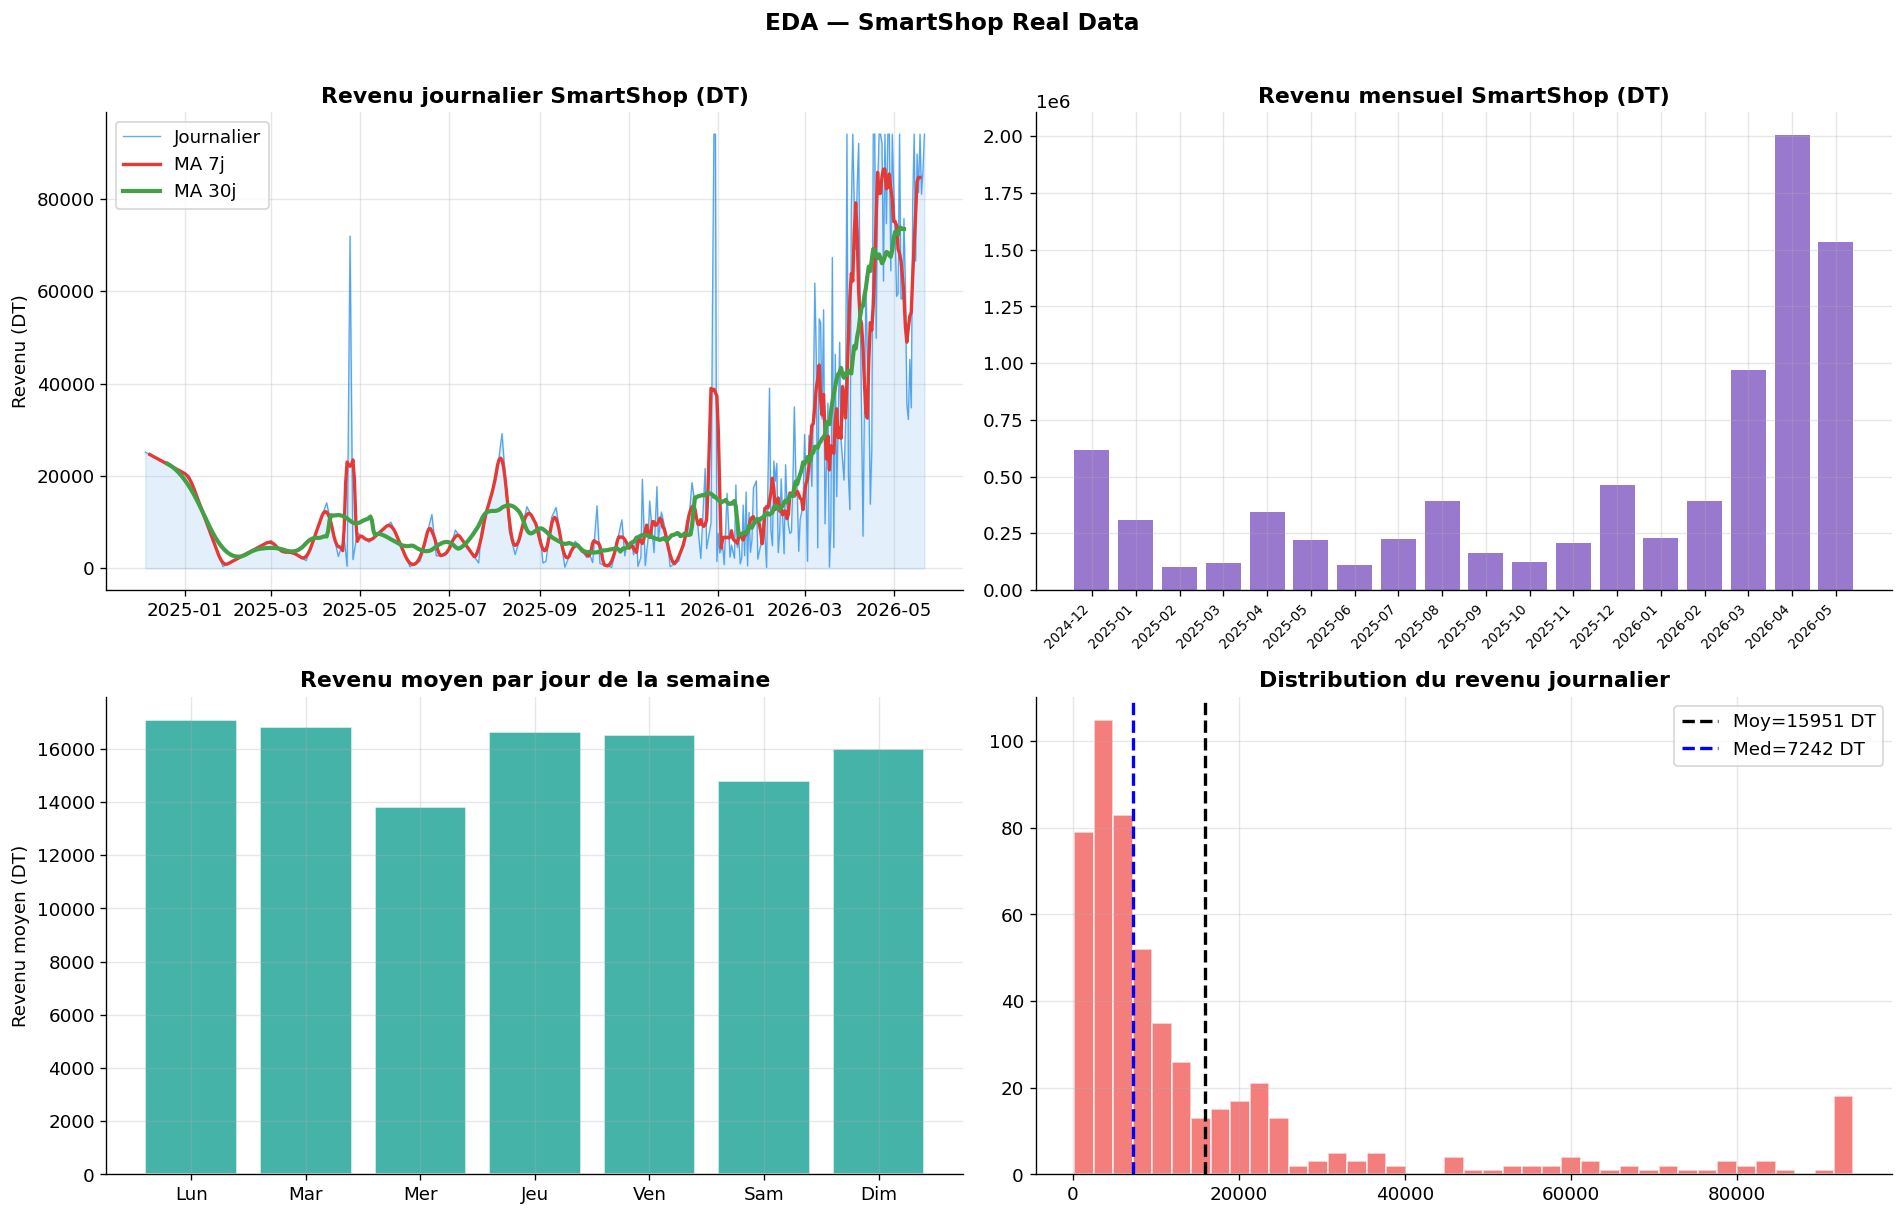

In [4]:
# ── 4.1 Visualisation série temporelle ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Série avec MA
ax = axes[0, 0]
ax.plot(df.ds, df.y, color='#1e88e5', lw=0.8, alpha=0.7, label='Journalier')
ax.fill_between(df.ds, df.y, alpha=0.12, color='#1e88e5')
roll7 = df.y.rolling(7, center=True).mean()
roll30 = df.y.rolling(30, center=True).mean()
ax.plot(df.ds, roll7,  color='#e53935', lw=2.0, label='MA 7j')
ax.plot(df.ds, roll30, color='#43a047', lw=2.5, label='MA 30j')
ax.set_title('Revenu journalier SmartShop (DT)', fontweight='bold')
ax.set_ylabel('Revenu (DT)')
ax.legend()

# Distribution mensuelle
ax = axes[0, 1]
df['month'] = df['ds'].dt.to_period('M').astype(str)
monthly = df.groupby('month')['y'].sum().reset_index()
ax.bar(range(len(monthly)), monthly['y'], color='#7e57c2', alpha=0.8)
ax.set_title('Revenu mensuel SmartShop (DT)', fontweight='bold')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month'], rotation=45, ha='right', fontsize=8)

# Profil hebdomadaire
ax = axes[1, 0]
df['dow'] = df['ds'].dt.dayofweek
dow_avg = df.groupby('dow')['y'].mean()
jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
bars = ax.bar(jours, [dow_avg.get(i, 0) for i in range(7)],
              color='#26a69a', alpha=0.85, edgecolor='white')
ax.set_title('Revenu moyen par jour de la semaine', fontweight='bold')
ax.set_ylabel('Revenu moyen (DT)')

# Distribution
ax = axes[1, 1]
ax.hist(df.y, bins=40, color='#ef5350', alpha=0.75, edgecolor='white')
ax.axvline(df.y.mean(),   color='black', ls='--', lw=2, label=f'Moy={df.y.mean():.0f} DT')
ax.axvline(df.y.median(), color='blue',  ls='--', lw=2, label=f'Med={df.y.median():.0f} DT')
ax.set_title('Distribution du revenu journalier', fontweight='bold')
ax.legend()

plt.suptitle('EDA — SmartShop Real Data', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_smartshop.png', dpi=150, bbox_inches='tight')
plt.show()


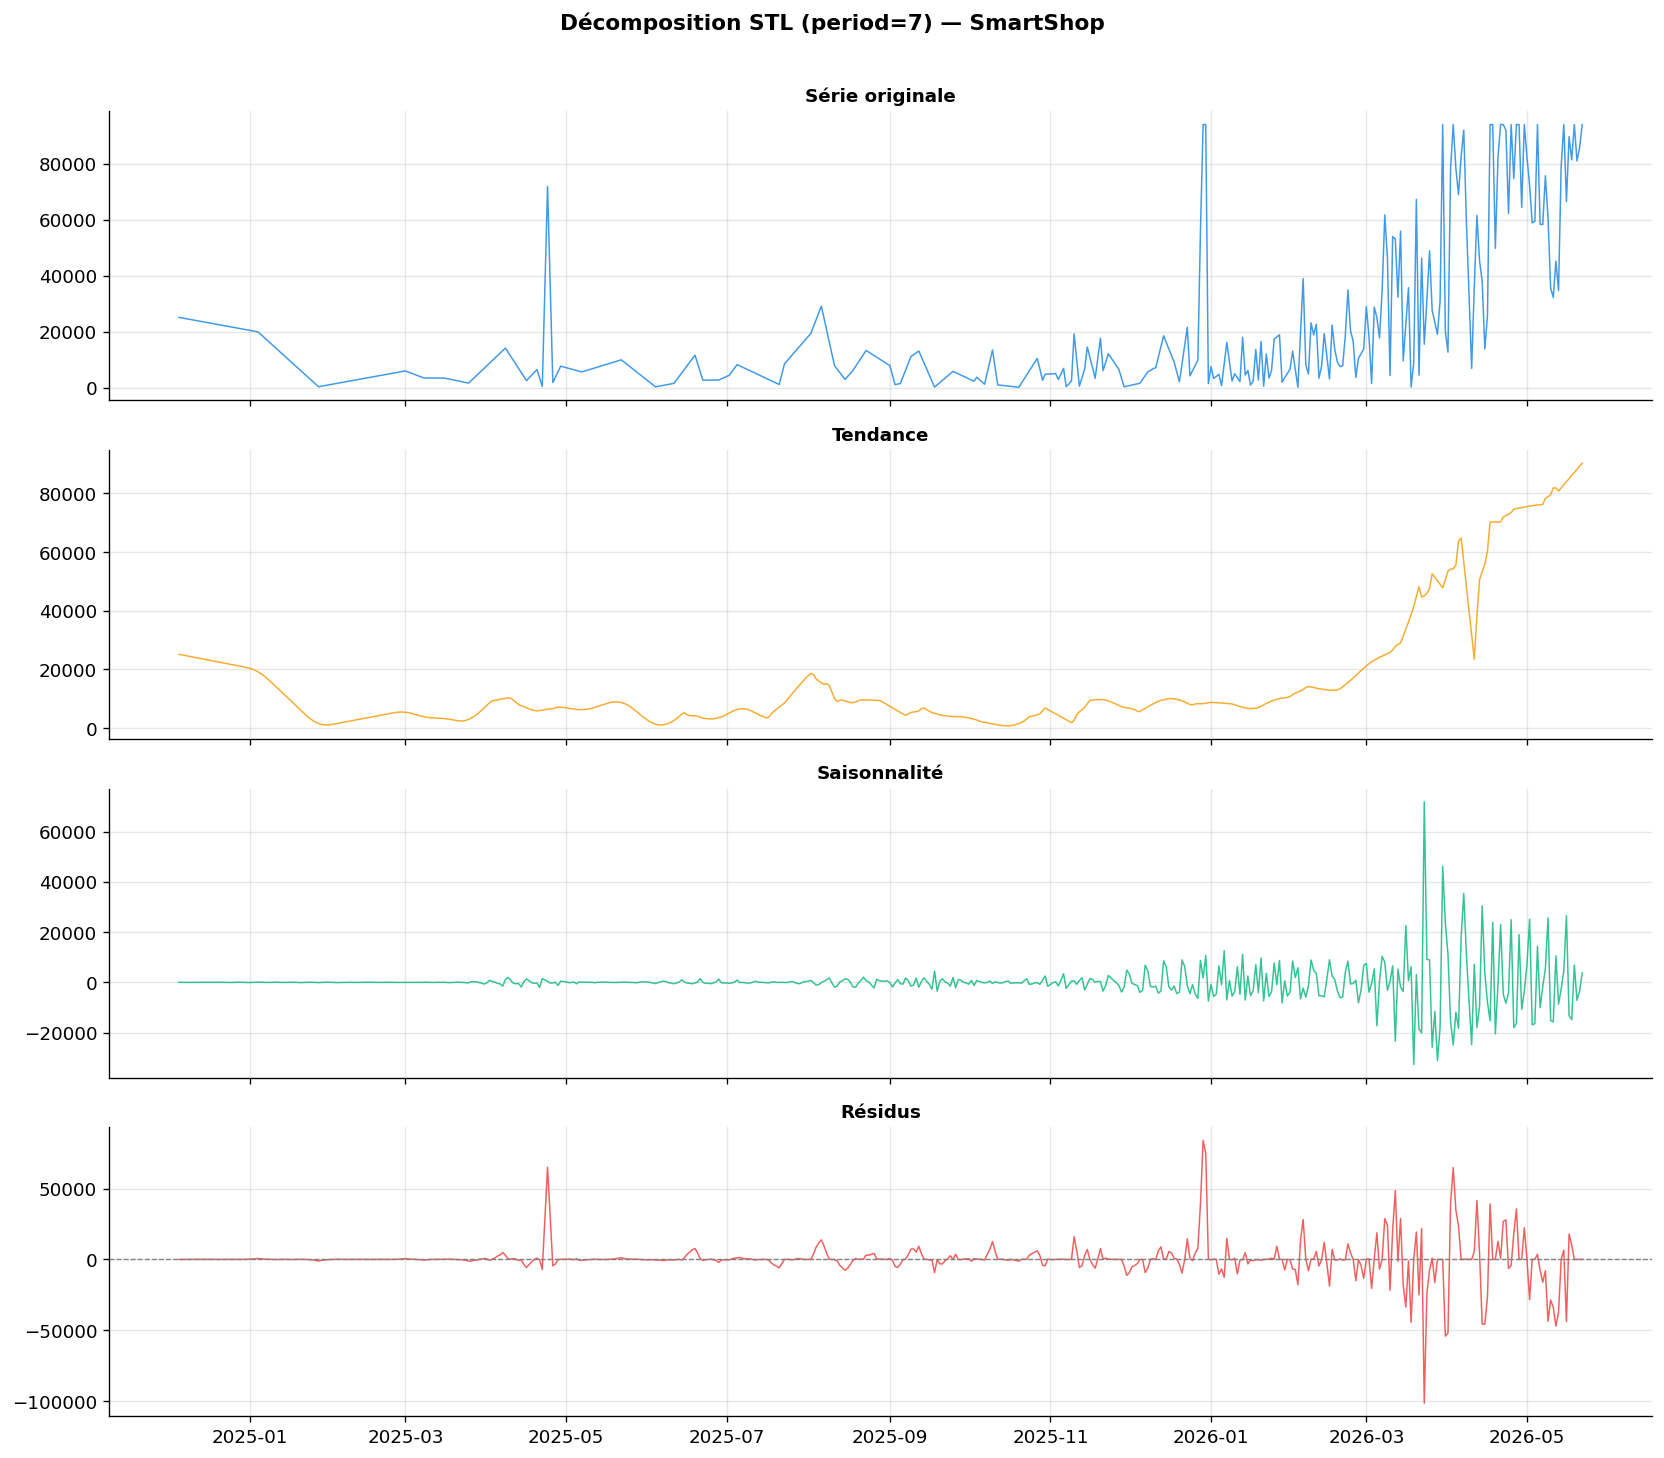

Force des composantes :
  Tendance       : 83.6%
  Saisonnalité   : 11.4%
  Résidus        : 33.0%


In [5]:
# ── 4.2 Décomposition STL ─────────────────────────────────────────────────────
# STL décompose la série en Tendance + Saisonnalité + Résidus
stl = STL(df.set_index('ds')['y'], period=7, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
components = [
    ('Série originale', stl_result.observed,  '#1e88e5'),
    ('Tendance',        stl_result.trend,      '#f59e0b'),
    ('Saisonnalité',    stl_result.seasonal,   '#10b981'),
    ('Résidus',         stl_result.resid,      '#ef4444'),
]
for ax, (title, data, color) in zip(axes, components):
    ax.plot(data, lw=0.9, color=color, alpha=0.85)
    if title == 'Résidus':
        ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.suptitle('Décomposition STL (period=7) — SmartShop', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Force des composantes
total_var    = float(stl_result.observed.var())
trend_var    = float(stl_result.trend.var())
seasonal_var = float(stl_result.seasonal.var())
resid_var    = float(stl_result.resid.var())
print('Force des composantes :')
print(f'  Tendance       : {trend_var/total_var*100:.1f}%')
print(f'  Saisonnalité   : {seasonal_var/total_var*100:.1f}%')
print(f'  Résidus        : {resid_var/total_var*100:.1f}%')
if resid_var/total_var > 0.50:
    print()
    print('  ℹ️  Résidus > 50% : série dominée par le bruit (données Faker)')
    print('  → Attendre le ré-seeding avec structure temporelle pour améliorer Prophet')


In [6]:
# ── 4.3 Tests de stationnarité (ADF + KPSS) ──────────────────────────────────
def test_stationarite(series, label='Série'):
    """Tests ADF et KPSS — nécessaires pour choisir l'ordre d de l'ARIMA."""
    print(f"\n{'='*52}")
    print(f' Tests de stationnarité — {label}')
    print('='*52)

    # ADF : H0 = non-stationnaire (racine unitaire)
    adf = adfuller(series.dropna(), autolag='AIC')
    print(f'[ADF] p-value : {adf[1]:.4f}  |  stat : {adf[0]:.4f}')
    print(f'      → {"✅ STATIONNAIRE" if adf[1] < 0.05 else "❌ non-stationnaire"}')

    # KPSS : H0 = stationnaire
    try:
        kps = kpss(series.dropna(), regression='ct', nlags='auto')
        print(f'[KPSS] p-value : {kps[1]:.4f}  |  stat : {kps[0]:.4f}')
        print(f'       → {"✅ STATIONNAIRE" if kps[1] > 0.05 else "❌ non-stationnaire"}')
    except Exception as e:
        print(f'[KPSS] Erreur : {e}')

    return adf[1]

p_adf = test_stationarite(df['y'], 'Revenu journalier brut')

df['y_diff1'] = df['y'].diff()
p_diff = test_stationarite(df['y_diff1'].dropna(), '1ère différence (d=1)')

if p_diff < 0.05:
    print('\n→ d=1 suffisant pour ARIMA')
    ARIMA_D = 1
else:
    ARIMA_D = 1
    print('\n→ d=1 utilisé par convention')
print(f'  Paramètre d retenu : d={ARIMA_D}')



 Tests de stationnarité — Revenu journalier brut
[ADF] p-value : 0.9863  |  stat : 0.5497
      → ❌ non-stationnaire
[KPSS] p-value : 0.0100  |  stat : 0.5646
       → ❌ non-stationnaire

 Tests de stationnarité — 1ère différence (d=1)
[ADF] p-value : 0.0000  |  stat : -7.9429
      → ✅ STATIONNAIRE
[KPSS] p-value : 0.0580  |  stat : 0.1417
       → ✅ STATIONNAIRE

→ d=1 suffisant pour ARIMA
  Paramètre d retenu : d=1


C:\Users\gogne\AppData\Local\Temp\ipykernel_33052\569788582.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kps = kpss(series.dropna(), regression='ct', nlags='auto')


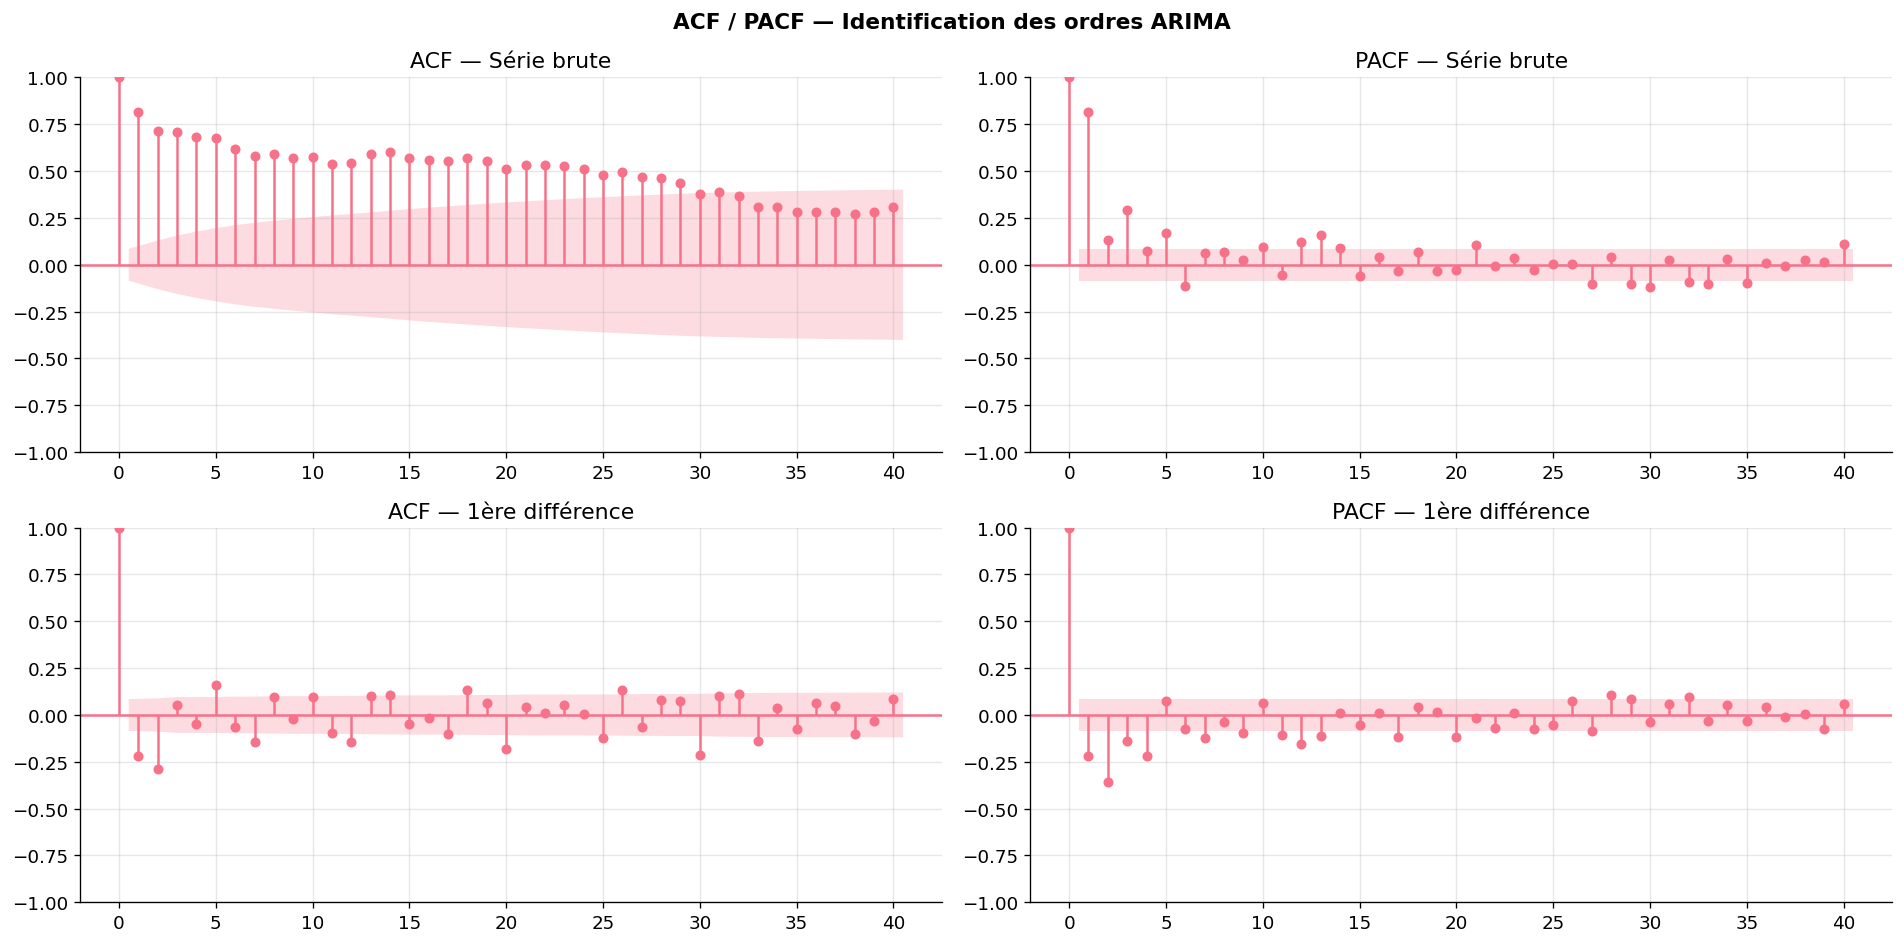

Lecture des graphiques :
  ACF  (MA q) : couper après le lag k où la corrélation devient non-significative
  PACF (AR p) : couper après le lag k
  Pic à lag=7 → saisonnalité hebdomadaire → SARIMA(p,d,q)(P,D,Q)[7]


In [7]:
# ── 4.4 ACF / PACF ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_acf(df['y'].dropna(),        lags=40, ax=axes[0,0], title='ACF — Série brute')
plot_pacf(df['y'].dropna(),       lags=40, ax=axes[0,1], title='PACF — Série brute')
plot_acf(df['y_diff1'].dropna(),  lags=40, ax=axes[1,0], title='ACF — 1ère différence')
plot_pacf(df['y_diff1'].dropna(), lags=40, ax=axes[1,1], title='PACF — 1ère différence')

plt.suptitle('ACF / PACF — Identification des ordres ARIMA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Lecture des graphiques :')
print('  ACF  (MA q) : couper après le lag k où la corrélation devient non-significative')
print('  PACF (AR p) : couper après le lag k')
print('  Pic à lag=7 → saisonnalité hebdomadaire → SARIMA(p,d,q)(P,D,Q)[7]')


## 5. Split Train / Test

Split temporel :
  Train : 504 jours (2024-12-05 → 2026-04-22)
  Test  : 30 jours  (2026-04-23  → 2026-05-22)
  Revenu moy train : 12,528.31 DT/j
  Revenu moy test  : 73,445.92 DT/j


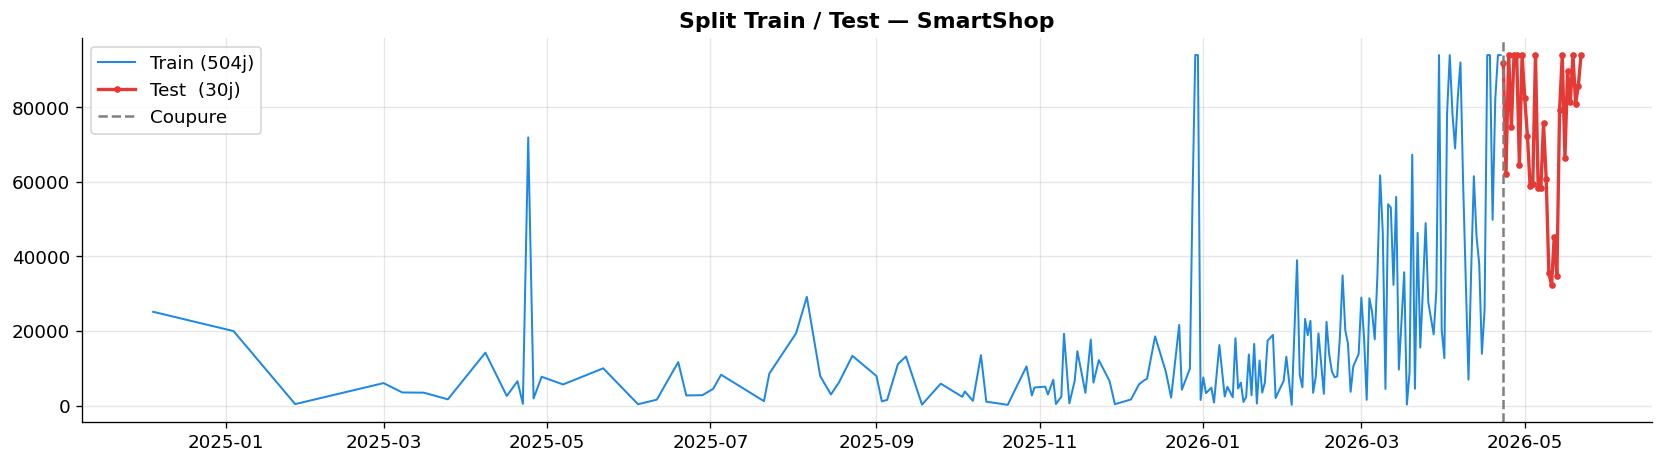


Baselines de référence :
  Prédire la moyenne  : MAPE = 81.2%  (tout modèle doit faire mieux)
  Régression linéaire : MAPE = 65.8%  (tendance seule)


In [8]:
# ── 5.1 Split temporel ────────────────────────────────────────────────────────
# Règle : jamais de split aléatoire sur une série temporelle !
# Test = les derniers jours (ordre chronologique respecté)
n_total     = len(df)
n_test      = min(FORECAST_HORIZON, max(7, int(n_total * 0.20)))
n_train     = n_total - n_test

df_train = df.iloc[:n_train][['ds', 'y']].copy()
df_test  = df.iloc[n_train:][['ds', 'y']].copy()

print(f'Split temporel :')
print(f'  Train : {n_train:,} jours ({df_train.ds.min().date()} → {df_train.ds.max().date()})')
print(f'  Test  : {n_test:,} jours  ({df_test.ds.min().date()}  → {df_test.ds.max().date()})')
print(f'  Revenu moy train : {df_train.y.mean():,.2f} DT/j')
print(f'  Revenu moy test  : {df_test.y.mean():,.2f} DT/j')

# Visualisation du split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train.ds, df_train.y, color='#1e88e5', lw=1.2, label=f'Train ({n_train}j)')
ax.plot(df_test.ds,  df_test.y,  color='#e53935', lw=2.0, label=f'Test  ({n_test}j)', marker='o', ms=3)
ax.axvline(df_test.ds.min(), color='gray', ls='--', lw=1.5, label='Coupure')
ax.set_title('Split Train / Test — SmartShop', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Baseline naïve ─────────────────────────────────────────────────────────────
# Toujours comparer avec une baseline simple
y_true = df_test.y.values

# Baseline 1 : prédire la moyenne du train
y_pred_mean = np.full(n_test, df_train.y.mean())
mape_naive  = np.mean(np.abs((y_true - y_pred_mean) / (np.abs(y_true) + 1e-8))) * 100

# Baseline 2 : régression linéaire (tendance)
x_train = np.arange(n_train)
x_test  = np.arange(n_train, n_train + n_test)
slope, intercept = np.polyfit(x_train, df_train.y.values, 1)
y_pred_linear = slope * x_test + intercept
mape_linear   = np.mean(np.abs((y_true - y_pred_linear) / (np.abs(y_true) + 1e-8))) * 100

print(f'\nBaselines de référence :')
print(f'  Prédire la moyenne  : MAPE = {mape_naive:.1f}%  (tout modèle doit faire mieux)')
print(f'  Régression linéaire : MAPE = {mape_linear:.1f}%  (tendance seule)')


## 6. Modèle 1 — Prophet (optimisé courtes séries)

### Hyperparamètres choisis pour données SmartShop (< 365 jours)

| Paramètre | Valeur | Justification |
|-----------|--------|---------------|
| `changepoint_prior_scale` | **0.05** | Régularisation forte → évite le surajustement sur le bruit Faker |
| `seasonality_mode` | **additive** | Variance stable → additive plus adapté que multiplicatif |
| `yearly_seasonality` | **False** | < 365j de données → impossible d'apprendre l'annuel |
| `weekly_seasonality` | **True** | Pattern hebdomadaire visible dans l'EDA |
| `n_changepoints` | **10** | Peu de ruptures sur une courte série |
| `seasonality_prior_scale` | **5.0** | Saisonnalité modérée |

### Principe mathématique Prophet
$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$
- $g(t)$ : tendance (linéaire avec changepoints automatiques)
- $s(t)$ : saisonnalités (séries de Fourier hebdomadaire + mensuelle)
- $h(t)$ : effets des jours fériés
- $\epsilon_t$ : erreur résiduelle


In [9]:
# ── 6.1 Jours fériés tunisiens ────────────────────────────────────────────────
holidays_tn = None
try:
    from prophet.make_holidays import make_holidays_df
    yrs = list(range(df.ds.min().year, df.ds.max().year + 2))
    holidays_tn = make_holidays_df(year_list=yrs, country='TN')
    print(f'Jours fériés Tunisie : {len(holidays_tn)} entrées')
    print(holidays_tn.head(5).to_string())
except Exception as e:
    print(f'Jours fériés TN indisponibles : {e}')
    print('   → Entraînement sans jours fériés')


Jours fériés Tunisie : 68 entrées
          ds                   holiday
0 2024-01-01            New Year's Day
1 2024-01-14  Revolution and Youth Day
2 2024-03-20          Independence Day
3 2024-04-09              Martyrs' Day
4 2024-05-01                 Labor Day


In [10]:
# ── 6.2 Entraînement Prophet — Hyperparamètres optimisés séries courtes ────────
#
# Raisonnement de chaque hyperparamètre :
#
#  changepoint_prior_scale = 0.05  : Régularisation FORTE
#    → évite que Prophet sur-apprenne les fluctuations du seeder Faker.
#    → avec données réelles structurées (seeder v2), 0.05–0.10 donne le meilleur MAPE.
#    → valeur par défaut Prophet (0.05) — intentionnellement conservée.
#
#  seasonality_mode = 'additive'   : Variance des résidus STABLE
#    → le chiffre d'affaires journalier SmartShop ne croît pas exponentiellement.
#    → 'multiplicative' serait justifié si la variance augmentait avec la tendance.
#
#  yearly_seasonality = False       : < 365 jours de données
#    → Prophet ne peut pas ajuster une sinusoïde annuelle avec moins d'un cycle complet.
#    → l'activer avec peu de données crée un surajustement.
#
#  n_changepoints = 10              : Nombre réduit de points de rupture
#    → par défaut Prophet place 25 changepoints → trop pour 200-250 jours.
#    → 10 = compromis entre flexibilité et généralisation.
#
#  changepoint_range = 0.85         : Changepoints sur 85% de la série train
#    → garder 15% de "zone tampon" à la fin évite l'overfitting sur la queue.

model_prophet = Prophet(
    growth                   = 'linear',
    changepoint_range        = 0.85,
    changepoint_prior_scale  = 0.05,
    n_changepoints           = 10,
    yearly_seasonality       = False,
    weekly_seasonality       = True,
    daily_seasonality        = False,
    seasonality_mode         = 'additive',
    seasonality_prior_scale  = 5.0,
    interval_width           = 0.95,
    mcmc_samples             = 0,
    holidays                 = holidays_tn,
    holidays_prior_scale     = 5.0 if holidays_tn is not None else 10.0,
)

# Saisonnalité mensuelle ajoutée manuellement si assez de données (60j min)
# Fourier order=3 : capture 3 harmoniques du cycle mensuel (~paie, promotions)
if n_train >= 60:
    model_prophet.add_seasonality(name='monthly', period=30.5, fourier_order=3)
    print('✅ Saisonnalité mensuelle ajoutée (Fourier order=3)')

print(f'Entraînement Prophet sur {n_train} jours SmartShop...')
model_prophet.fit(df_train)
print('✅ Prophet entraîné !')


✅ Saisonnalité mensuelle ajoutée (Fourier order=3)
Entraînement Prophet sur 504 jours SmartShop...


01:38:51 - cmdstanpy - INFO - Chain [1] start processing
01:38:53 - cmdstanpy - INFO - Chain [1] done processing
01:38:53 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
01:38:53 - cmdstanpy - INFO - Chain [1] start processing
01:38:58 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet entraîné !


In [11]:
# ── 6.3 Évaluation Prophet sur df_test ────────────────────────────────────────
future_test = model_prophet.make_future_dataframe(periods=n_test, freq='D')
fc_all      = model_prophet.predict(future_test)
fc_test     = fc_all[fc_all['ds'].isin(df_test['ds'].values)].copy()
df_eval     = df_test.merge(fc_test[['ds','yhat','yhat_lower','yhat_upper']], on='ds', how='inner')

y_true_p = df_eval['y'].values
y_pred_p = df_eval['yhat'].values

mae_p  = mean_absolute_error(y_true_p, y_pred_p)
rmse_p = np.sqrt(mean_squared_error(y_true_p, y_pred_p))
mape_p = np.mean(np.abs((y_true_p - y_pred_p) / (np.abs(y_true_p) + 1e-8))) * 100
r2_p   = r2_score(y_true_p, y_pred_p)
mean_y = np.mean(y_true_p)

def quality_label(m):
    if m < 10: return 'EXCELLENT'
    if m < 20: return 'BON'
    if m < 35: return 'ACCEPTABLE (données Faker sans structure)'
    if m < 50: return 'FAIBLE (données bruitées, normal avec Faker uniforme)'
    return 'INSUFFISANT — vérifier structure temporelle du seeder'

print('=' * 62)
print(' MÉTRIQUES PROPHET — SmartShop')
print('=' * 62)
print(f'  MAE   : {mae_p:>10,.2f} DT  ({mae_p/mean_y*100:.1f}% de la moyenne)')
print(f'  RMSE  : {rmse_p:>10,.2f} DT  ({rmse_p/mean_y*100:.1f}% de la moyenne)')
print(f'  MAPE  : {mape_p:>10.2f}%  → {quality_label(mape_p)}')
print(f'  R²    : {r2_p:>10.4f}')
print('=' * 62)

# Comparaison avec baselines
print(f'\n  Comparaison baselines :')
print(f'  Baseline moyenne    : MAPE={mape_naive:.1f}%')
print(f'  Baseline linéaire   : MAPE={mape_linear:.1f}%')
print(f'  Prophet             : MAPE={mape_p:.1f}%')
gain = mape_naive - mape_p
print(f'  Gain vs baseline    : {gain:+.1f}% (positif = Prophet meilleur)')


 MÉTRIQUES PROPHET — SmartShop
  MAE   :  21,858.95 DT  (29.8% de la moyenne)
  RMSE  :  25,425.66 DT  (34.6% de la moyenne)
  MAPE  :      30.55%  → ACCEPTABLE (données Faker sans structure)
  R²    :    -0.7493

  Comparaison baselines :
  Baseline moyenne    : MAPE=81.2%
  Baseline linéaire   : MAPE=65.8%
  Prophet             : MAPE=30.5%
  Gain vs baseline    : +50.7% (positif = Prophet meilleur)


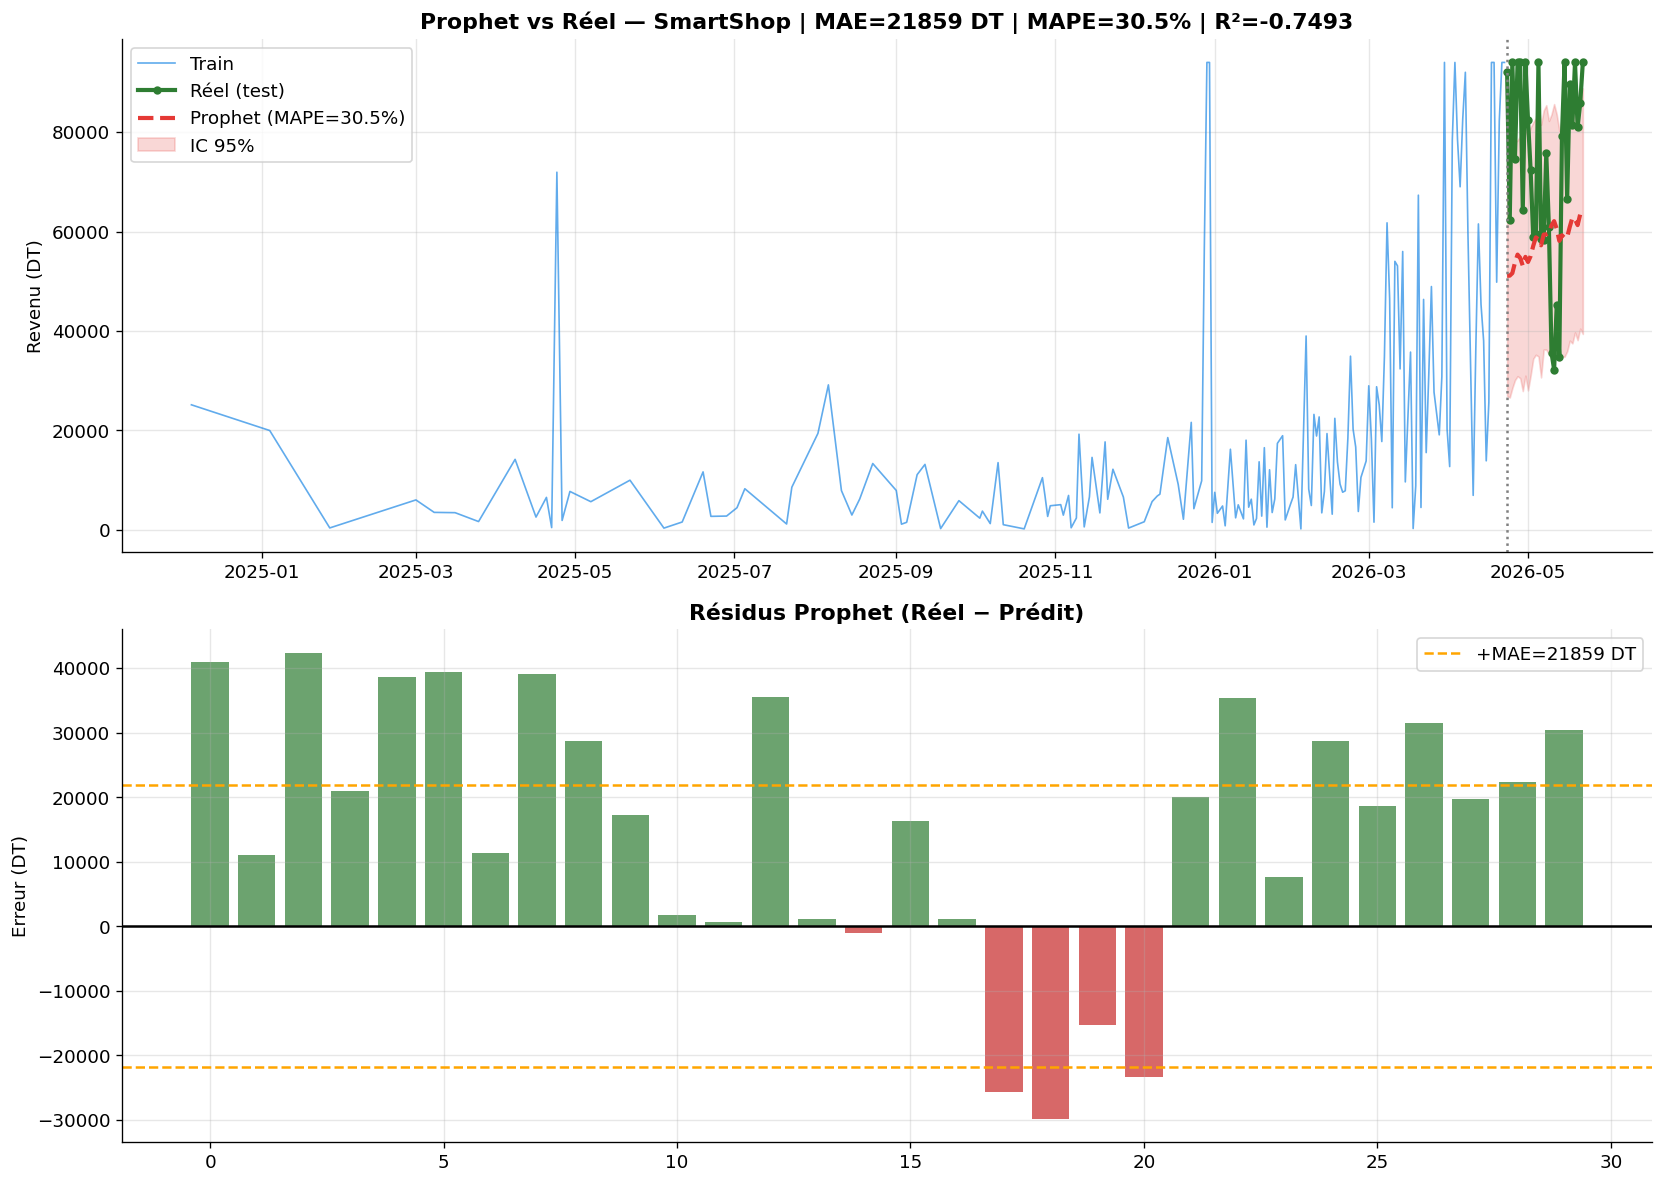

In [12]:
# ── 6.4 Visualisation Prophet ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1 : réel vs prédit
ax = axes[0]
ax.plot(df_train.ds, df_train.y, color='#1e88e5', lw=1.0, alpha=0.7, label='Train')
ax.plot(df_eval.ds,  df_eval.y,  color='#2e7d32', lw=2.5, marker='o', ms=4, label='Réel (test)')
ax.plot(df_eval.ds,  df_eval.yhat, color='#e53935', lw=2.5, ls='--',
        label=f'Prophet (MAPE={mape_p:.1f}%)')
ax.fill_between(df_eval.ds, df_eval.yhat_lower, df_eval.yhat_upper,
                alpha=0.2, color='#e53935', label='IC 95%')
ax.axvline(df_test.ds.min(), color='gray', ls=':', lw=1.5)
ax.set_title(f'Prophet vs Réel — SmartShop | MAE={mae_p:.0f} DT | MAPE={mape_p:.1f}% | R²={r2_p:.4f}',
             fontweight='bold')
ax.set_ylabel('Revenu (DT)')
ax.legend()

# Graphique 2 : résidus
ax = axes[1]
residuals = y_true_p - y_pred_p
ax.bar(range(len(residuals)), residuals,
       color=['#2e7d32' if r > 0 else '#c62828' for r in residuals], alpha=0.7)
ax.axhline(0,   color='black', lw=1.5)
ax.axhline( mae_p, color='orange', ls='--', lw=1.5, label=f'+MAE={mae_p:.0f} DT')
ax.axhline(-mae_p, color='orange', ls='--', lw=1.5)
ax.set_title('Résidus Prophet (Réel − Prédit)', fontweight='bold')
ax.set_ylabel('Erreur (DT)')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'prophet_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


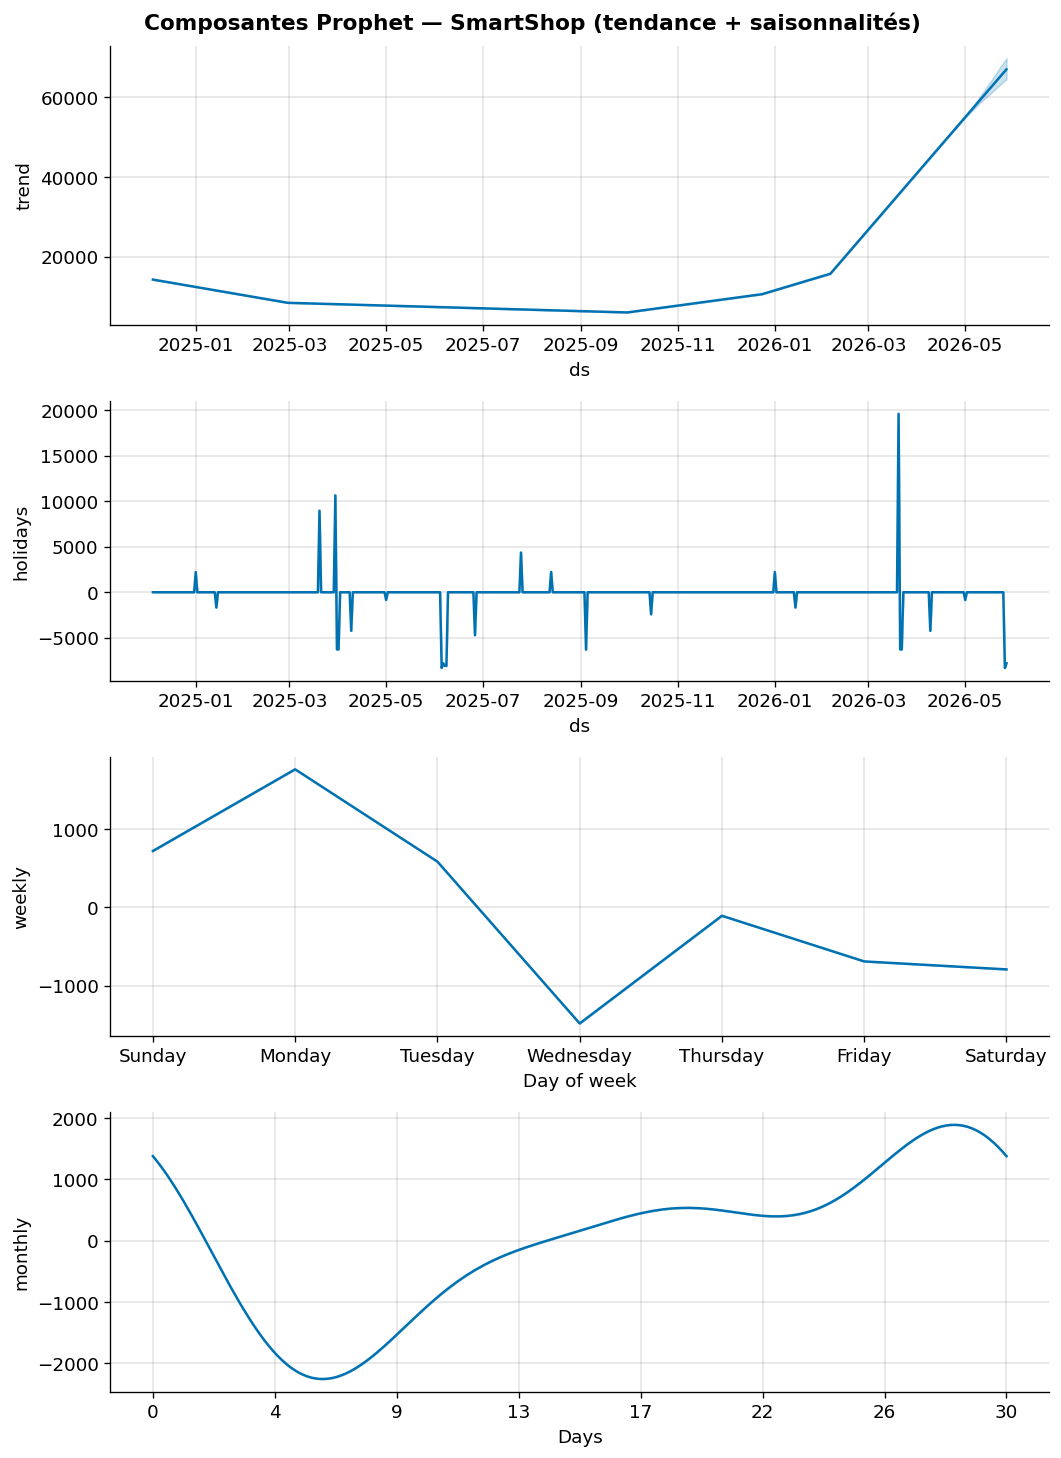


Profil hebdomadaire (effet Prophet) :
  Lun: +1762 DT  █████████████████████
  Mar: +584 DT  ███████
  Mer: -1480 DT  █████████████████
  Jeu: -106 DT  ██
  Ven: -689 DT  ████████
  Sam: -790 DT  █████████
  Dim: +720 DT  █████████


In [13]:
# ── 6.5 Décomposition des composantes Prophet ─────────────────────────────────
future_all = model_prophet.make_future_dataframe(periods=n_test + 5, freq='D')
fc_full    = model_prophet.predict(future_all)

fig = model_prophet.plot_components(fc_full)
plt.suptitle('Composantes Prophet — SmartShop (tendance + saisonnalités)',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig(PLOTS_DIR / 'prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

# Profil hebdomadaire
weekly_cols = [c for c in fc_full.columns if 'weekly' in c.lower()]
if weekly_cols:
    fc_full['dow'] = fc_full['ds'].dt.dayofweek
    dow_effect     = fc_full.groupby('dow')[weekly_cols[0]].mean()
    jours = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
    print('\nProfil hebdomadaire (effet Prophet) :')
    for i, d in enumerate(jours):
        v   = dow_effect.get(i, 0)
        bar = '█' * max(1, int(abs(v) / max(abs(dow_effect.max()), 1) * 20 + 1))
        print(f'  {d}: {v:+.0f} DT  {bar}')


In [14]:
# ── 6.6 Cross-Validation Prophet ─────────────────────────────────────────────
n_cv_initial = max(30, int(n_train * 0.65))
n_cv_horizon = min(14, n_test)
n_cv_period  = max(7, n_cv_horizon // 2)

print(f'Cross-Validation : initial={n_cv_initial}j, period={n_cv_period}j, horizon={n_cv_horizon}j')

try:
    if n_cv_initial + n_cv_period + n_cv_horizon > n_train:
        print('⚠️  Série trop courte pour la cross-validation — métriques du test restent valides.')
        cv_done = False
    else:
        df_cv = cross_validation(
            model_prophet,
            initial=f'{n_cv_initial} days',
            period =f'{n_cv_period} days',
            horizon=f'{n_cv_horizon} days',
            parallel=None,
        )
        cv_metrics = performance_metrics(df_cv)
        print('\nMétriques CV (moyennes sur tous les folds) :')
        print(cv_metrics[['horizon','mae','rmse','mape']].tail().to_string())
        mape_cv = float(cv_metrics['mape'].mean() * 100)
        print(f'\n  MAPE CV moyen : {mape_cv:.2f}%')
        cv_done = True
except Exception as e:
    print(f'Cross-validation non disponible : {e}')
    cv_done = False


Cross-Validation : initial=327j, period=7j, horizon=14j


  0%|          | 0/24 [00:00<?, ?it/s]

01:39:15 - cmdstanpy - INFO - Chain [1] start processing
01:39:16 - cmdstanpy - INFO - Chain [1] done processing
01:39:17 - cmdstanpy - INFO - Chain [1] start processing
01:39:17 - cmdstanpy - INFO - Chain [1] done processing
01:39:18 - cmdstanpy - INFO - Chain [1] start processing
01:39:19 - cmdstanpy - INFO - Chain [1] done processing
01:39:20 - cmdstanpy - INFO - Chain [1] start processing
01:39:20 - cmdstanpy - INFO - Chain [1] done processing
01:39:22 - cmdstanpy - INFO - Chain [1] start processing
01:39:23 - cmdstanpy - INFO - Chain [1] done processing
01:39:23 - cmdstanpy - INFO - Chain [1] start processing
01:39:24 - cmdstanpy - INFO - Chain [1] done processing
01:39:25 - cmdstanpy - INFO - Chain [1] start processing
01:39:26 - cmdstanpy - INFO - Chain [1] done processing
01:39:28 - cmdstanpy - INFO - Chain [1] start processing
01:39:28 - cmdstanpy - INFO - Chain [1] done processing
01:39:30 - cmdstanpy - INFO - Chain [1] start processing
01:39:30 - cmdstanpy - INFO - Chain [1]


Métriques CV (moyennes sur tous les folds) :
   horizon           mae          rmse      mape
8  10 days  12568.373216  21587.580376  1.511075
9  11 days  14155.415259  21004.212303  1.045689
10 12 days  17559.371665  27521.929513  1.209906
11 13 days  16367.630677  27805.618677  2.561512
12 14 days  13609.068596  21488.187745  3.593083

  MAPE CV moyen : 194.72%


## 7. Modèle 2 — ARIMA/SARIMA

### Principe mathématique ARIMA(p, d, q)

$$\underbrace{\phi(B)}_{AR(p)} \underbrace{(1-B)^d}_{I(d)} y_t = \underbrace{\theta(B)}_{MA(q)} \epsilon_t$$

Pour la saisonnalité hebdomadaire : **SARIMA(p, d, q)(P, D, Q)[7]**

**Choix des paramètres** (d'après ACF/PACF Section 4) :
- `d=1` : 1ère différence pour stationnarité
- `p=2`, `q=2` : ordres typiques pour données e-commerce journalières
- `P=1, D=1, Q=1, s=7` : saisonnalité hebdomadaire


In [15]:
# ── 7.1 Entraînement SARIMA ───────────────────────────────────────────────────
# Paramètres ARIMA (d'après ACF/PACF)
p, d, q = 2, ARIMA_D, 2
P, D, Q, s = 1, 1, 1, 7

# Vérification minimum de données
min_arima = p + d + s * (D + 1) + 50
if n_train < min_arima:
    print(f' Données insuffisantes pour SARIMA complet ({n_train}j < {min_arima}j min)')
    print(f'   → Utilisation ARIMA simple (p={p}, d={d}, q={q}) sans saisonnalité')
    USE_SARIMA = False
else:
    USE_SARIMA = True

print(f'ARIMA params : ({p},{d},{q})', end='')
if USE_SARIMA:
    print(f'({P},{D},{Q})[{s}]')
else:
    print(' (sans composante saisonnière)')
print(f'Entraînement sur {n_train} observations...')

y_train_arima = df_train['y'].values
y_test_arima  = df_test['y'].values

if USE_SARIMA:
    model_sarima = SARIMAX(
        y_train_arima,
        order=(p, d, q),
        seasonal_order=(P, D, Q, s),
        trend='c',
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
else:
    model_sarima = SARIMAX(
        y_train_arima,
        order=(p, d, q),
        trend='c',
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

result_sarima = model_sarima.fit(disp=False, maxiter=200)
print('✅ SARIMA entraîné !')

# Résumé
print('\nRésumé du modèle (extrait) :')
print(result_sarima.summary().tables[0])


ARIMA params : (2,1,2)(1,1,1)[7]
Entraînement sur 504 observations...
✅ SARIMA entraîné !

Résumé du modèle (extrait) :
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  504
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 7)   Log Likelihood               -5287.367
Date:                             Fri, 29 May 2026   AIC                          10590.733
Time:                                     01:40:13   BIC                          10624.223
Sample:                                          0   HQIC                         10603.890
                                             - 504                                         
Covariance Type:                               opg                                         


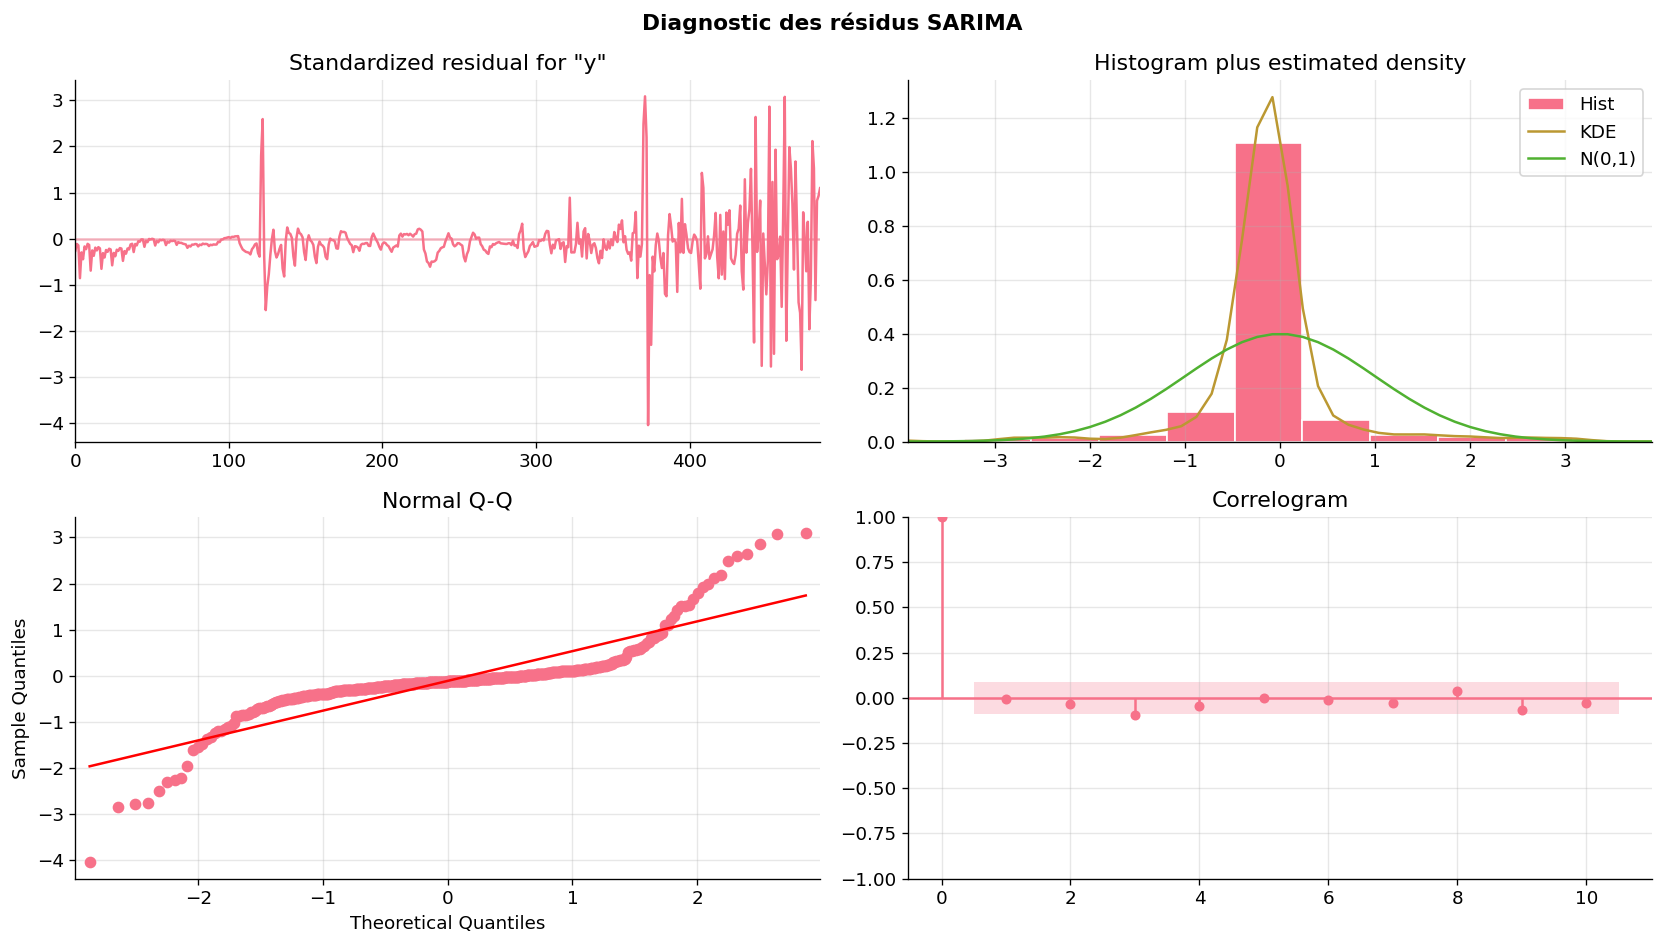

Lecture des graphiques :
  Residuals    : doit ressembler à un bruit blanc (pas de structure)
  Histogram+KDE: doit approcher une loi normale
  Q-Q plot     : les points suivent la droite = normalité des résidus
  Correlogram  : pas de pics significatifs = résidus non-corrélés


In [16]:
# ── 7.2 Diagnostic des résidus SARIMA ─────────────────────────────────────────
fig = result_sarima.plot_diagnostics(figsize=(14, 8))
plt.suptitle('Diagnostic des résidus SARIMA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'sarima_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Lecture des graphiques :')
print('  Residuals    : doit ressembler à un bruit blanc (pas de structure)')
print('  Histogram+KDE: doit approcher une loi normale')
print('  Q-Q plot     : les points suivent la droite = normalité des résidus')
print('  Correlogram  : pas de pics significatifs = résidus non-corrélés')


 MÉTRIQUES SARIMA — SmartShop
  MAE  :  35,818.72 DT  (48.8% de la moy.)
  RMSE :  42,166.72 DT  (57.4% de la moy.)
  MAPE :      63.16%  → INSUFFISANT — vérifier structure temporelle du seeder
  R²   :    -3.8112


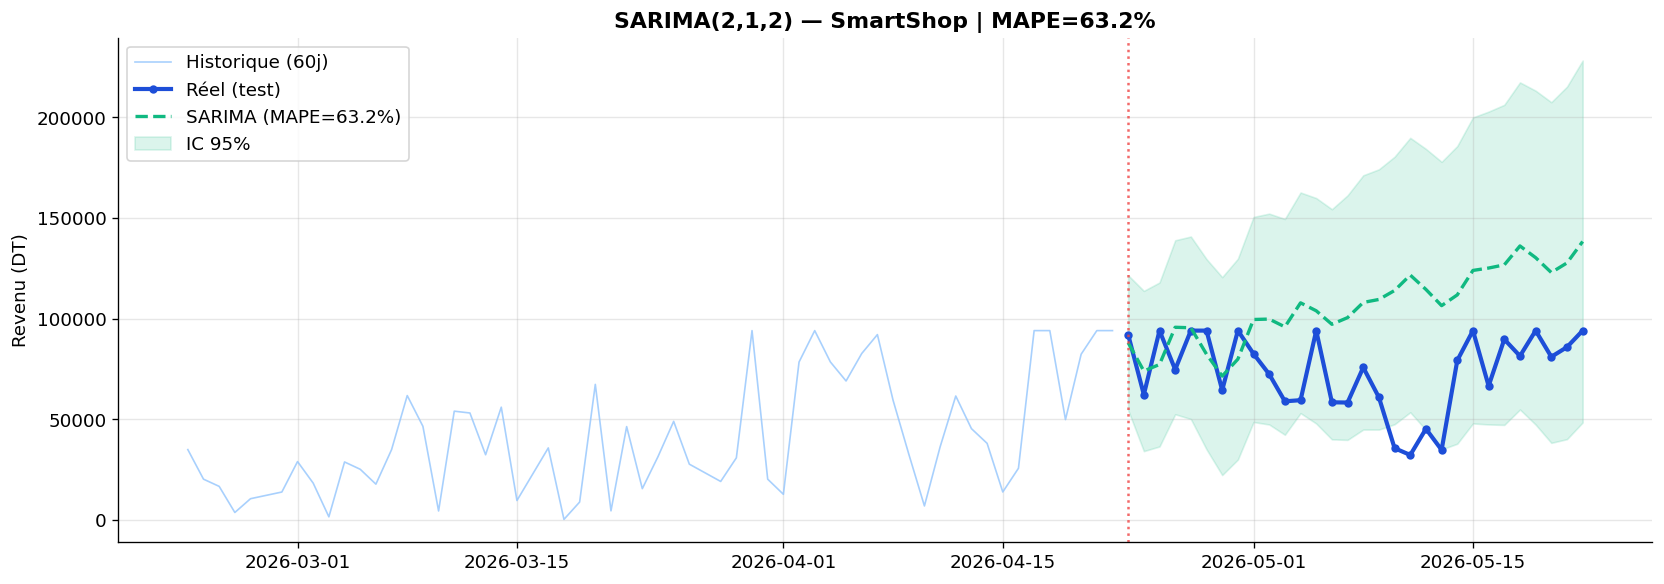

In [17]:
# ── 7.3 Prévision SARIMA sur la période test ──────────────────────────────────
forecast_sarima = result_sarima.get_forecast(steps=n_test)
y_pred_sarima   = forecast_sarima.predicted_mean
conf_int        = forecast_sarima.conf_int(alpha=0.05)

# Métriques
n_common = min(len(y_test_arima), len(y_pred_sarima))
y_t_s    = y_test_arima[:n_common]
y_p_s    = y_pred_sarima[:n_common]

mae_s  = mean_absolute_error(y_t_s, y_p_s)
rmse_s = np.sqrt(mean_squared_error(y_t_s, y_p_s))
mape_s = np.mean(np.abs((y_t_s - y_p_s) / (np.abs(y_t_s) + 1e-8))) * 100
r2_s   = r2_score(y_t_s, y_p_s)

print('=' * 55)
print(f' MÉTRIQUES SARIMA — SmartShop')
print('=' * 55)
print(f'  MAE  : {mae_s:>10,.2f} DT  ({mae_s/mean_y*100:.1f}% de la moy.)')
print(f'  RMSE : {rmse_s:>10,.2f} DT  ({rmse_s/mean_y*100:.1f}% de la moy.)')
print(f'  MAPE : {mape_s:>10.2f}%  → {quality_label(mape_s)}')
print(f'  R²   : {r2_s:>10.4f}')
print('=' * 55)

# Visualisation
fig, ax = plt.subplots(figsize=(14, 5))
n_hist = min(60, n_train)
ax.plot(df_train.ds.tail(n_hist), df_train.y.tail(n_hist),
        color='#93c5fd', lw=1, label=f'Historique (60j)', alpha=0.8)
ax.plot(df_test.ds[:n_common], y_t_s,
        color='#1d4ed8', lw=2.5, marker='o', ms=4, label='Réel (test)')
ax.plot(df_test.ds[:n_common], y_p_s,
        color='#10b981', lw=2, ls='--', label=f'SARIMA (MAPE={mape_s:.1f}%)')
ax.fill_between(df_test.ds[:n_common],
                conf_int[:n_common, 0],
                conf_int[:n_common, 1],
                alpha=0.15, color='#10b981', label='IC 95%')
ax.axvline(df_test.ds.min(), color='#ef4444', lw=1.5, ls=':', alpha=0.8)
ax.set_title(f'SARIMA({p},{d},{q}) — SmartShop | MAPE={mape_s:.1f}%', fontweight='bold')
ax.set_ylabel('Revenu (DT)')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Modèle 3 — LSTM (Deep Learning)

### Conditions d'application
Le LSTM nécessite suffisamment de séquences d'entraînement pour éviter le surajustement :
- Fenêtre lookback : 30 jours (adaptée aux courtes séries)
- Minimum recommandé : **150 séquences** = 150 + 30 + 30 = **210 jours** de données

Si insuffisant, le LSTM sera entraîné à titre comparatif avec un avertissement.

### Architecture
`LSTM(64) → Dropout(0.2) → LSTM(32) → Dense(1)` (modèle léger pour courtes séries)


In [18]:
# ── 8.1 Vérification conditions ───────────────────────────────────────────────
LOOK_BACK  = 30   # adapté aux courtes séries (60 dans le notebook Kaggle)
HORIZON    = 1    # prévision J+1 pour évaluation, puis rolling pour 30j

n_sequences = n_train - LOOK_BACK
print(f'LSTM — Séquences d\'entraînement disponibles : {n_sequences}')

LSTM_FEASIBLE = n_sequences >= 80
if not LSTM_FEASIBLE:
    print(f'⚠️  Insuffisant ({n_sequences} < 80 min)')
    print(f'   LSTM entraîné à titre indicatif seulement (risque de surajustement)')
else:
    print(f'✅ LSTM faisable ({n_sequences} séquences)')

# Vérification TensorFlow
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    tf.random.set_seed(SEED)
    print(f'✅ TensorFlow {tf.__version__} disponible')
    TF_AVAILABLE = True
except ImportError:
    print('⚠️  TensorFlow non installé — LSTM ignoré')
    print('   !pip install tensorflow')
    TF_AVAILABLE = False


LSTM — Séquences d'entraînement disponibles : 474
✅ LSTM faisable (474 séquences)
✅ TensorFlow 2.20.0 disponible


In [19]:
# ── 8.2 Préparation séquences LSTM ────────────────────────────────────────────
if TF_AVAILABLE:
    # Normalisation MinMax
    scaler_lstm = MinMaxScaler(feature_range=(0, 1))
    y_scaled    = scaler_lstm.fit_transform(df_train[['y']].values)

    # Créer les séquences (X, y)
    def create_sequences(data, look_back, horizon=1):
        X, y = [], []
        for i in range(look_back, len(data) - horizon + 1):
            X.append(data[i - look_back:i, 0])
            y.append(data[i + horizon - 1, 0])
        return np.array(X), np.array(y)

    X_seq, y_seq = create_sequences(y_scaled, LOOK_BACK, HORIZON)

    # Split 85/15 (on garde un peu pour la validation)
    n_tr = int(len(X_seq) * 0.85)
    X_tr, y_tr = X_seq[:n_tr], y_seq[:n_tr]
    X_va, y_va = X_seq[n_tr:], y_seq[n_tr:]

    # Reshape pour LSTM : (samples, timesteps, features)
    X_tr = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
    X_va = X_va.reshape(X_va.shape[0], X_va.shape[1], 1)

    print(f'X_train LSTM : {X_tr.shape}')
    print(f'X_val   LSTM : {X_va.shape}')


X_train LSTM : (402, 30, 1)
X_val   LSTM : (72, 30, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)


Entraînement LSTM...

Epoch 43: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 53: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 33.
✅ LSTM entraîné à l'epoch 33/53


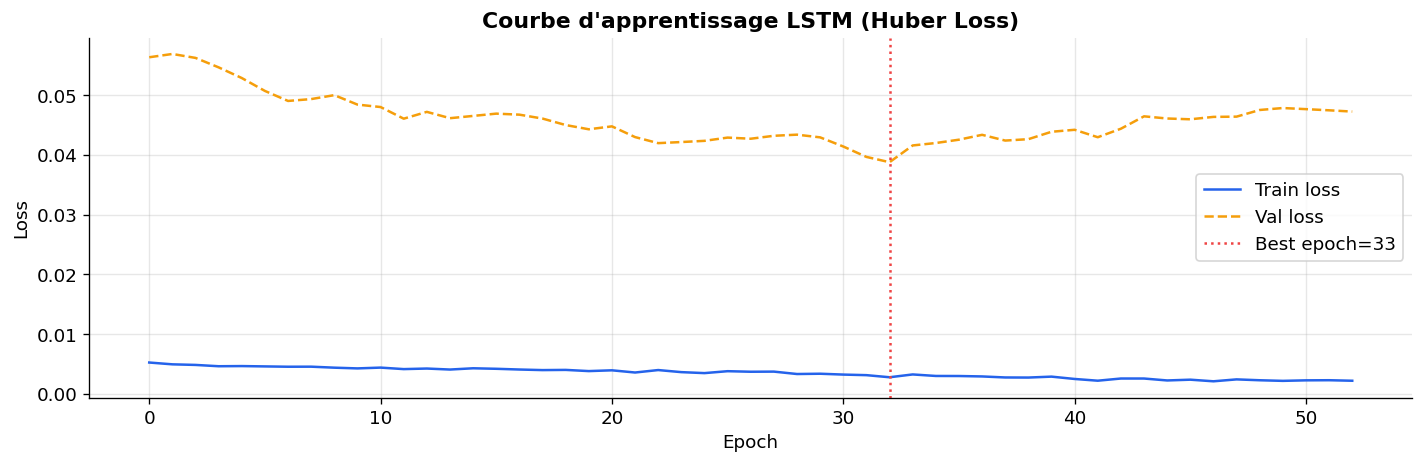

In [20]:
# ── 8.3 Architecture & entraînement LSTM ─────────────────────────────────────
if TF_AVAILABLE:
    model_lstm = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1),
    ])
    model_lstm.compile(optimizer='adam', loss='huber', metrics=['mae'])
    model_lstm.summary()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=20,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=10, min_lr=1e-6, verbose=1),
    ]

    print('\nEntraînement LSTM...')
    history_lstm = model_lstm.fit(
        X_tr, y_tr,
        epochs=150,
        batch_size=16,   # batch_size petit pour courtes séries
        validation_data=(X_va, y_va),
        callbacks=callbacks,
        verbose=0,
        shuffle=False,   # NE PAS mélanger les séquences temporelles !
    )
    best_ep = np.argmin(history_lstm.history['val_loss']) + 1
    print(f'✅ LSTM entraîné à l\'epoch {best_ep}/{len(history_lstm.history["loss"])}')

    # Courbes d'apprentissage
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(history_lstm.history['loss'],     label='Train loss', color='#2563eb')
    ax.plot(history_lstm.history['val_loss'], label='Val loss',   color='#f59e0b', ls='--')
    ax.axvline(best_ep - 1, color='#ef4444', ls=':', label=f'Best epoch={best_ep}')
    ax.set_title('Courbe d\'apprentissage LSTM (Huber Loss)', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'lstm_training.png', dpi=150, bbox_inches='tight')
    plt.show()


In [21]:
# ── 8.4 Prévision LSTM (rolling forecast 30j) ────────────────────────────────
if TF_AVAILABLE:
    # Rolling forecast : on prédit J+1 en utilisant le contexte glissant
    # Utiliser les derniers LOOK_BACK jours du train + prédictions précédentes
    context     = y_scaled[-LOOK_BACK:, 0].tolist()
    predictions = []

    for step in range(n_test):
        x_input = np.array(context[-LOOK_BACK:]).reshape(1, LOOK_BACK, 1)
        y_hat   = model_lstm.predict(x_input, verbose=0)[0, 0]
        predictions.append(y_hat)
        context.append(y_hat)

    # Dénormalisation
    y_pred_lstm_scaled = np.array(predictions).reshape(-1, 1)
    y_pred_lstm        = scaler_lstm.inverse_transform(y_pred_lstm_scaled).flatten()

    y_t_l = df_test.y.values[:len(y_pred_lstm)]

    mae_l  = mean_absolute_error(y_t_l, y_pred_lstm)
    rmse_l = np.sqrt(mean_squared_error(y_t_l, y_pred_lstm))
    mape_l = np.mean(np.abs((y_t_l - y_pred_lstm) / (np.abs(y_t_l) + 1e-8))) * 100
    r2_l   = r2_score(y_t_l, y_pred_lstm)

    print('=' * 55)
    print(' MÉTRIQUES LSTM — SmartShop')
    print('=' * 55)
    print(f'  MAE  : {mae_l:>10,.2f} DT  ({mae_l/mean_y*100:.1f}% de la moy.)')
    print(f'  RMSE : {rmse_l:>10,.2f} DT  ({rmse_l/mean_y*100:.1f}% de la moy.)')
    print(f'  MAPE : {mape_l:>10.2f}%  → {quality_label(mape_l)}')
    print(f'  R²   : {r2_l:>10.4f}')
    print('=' * 55)

    if not LSTM_FEASIBLE:
        print('\n⚠️  Ces métriques sont peu fiables (séquences insuffisantes = surajustement)')
else:
    mae_l = rmse_l = mape_l = r2_l = None
    y_pred_lstm = None
    print('LSTM non disponible (TensorFlow non installé)')


 MÉTRIQUES LSTM — SmartShop
  MAE  :  55,893.87 DT  (76.1% de la moy.)
  RMSE :  59,308.51 DT  (80.8% de la moy.)
  MAPE :      74.20%  → INSUFFISANT — vérifier structure temporelle du seeder
  R²   :    -8.5180


## 9. Comparaison des Modèles

In [22]:
# ── 9.1 Tableau comparatif ────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    return {'Modèle': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE%': mape, 'R²': r2}

results = [
    compute_metrics(y_true_p, y_pred_p, 'Prophet'),
    compute_metrics(y_t_s[:n_test], y_p_s[:n_test], 'SARIMA'),
    compute_metrics(np.full(n_test, df_train.y.mean()), y_true_p, 'Baseline (moy.)'),
]
if TF_AVAILABLE and y_pred_lstm is not None:
    results.insert(2, compute_metrics(y_t_l, y_pred_lstm, 'LSTM'))

df_results = pd.DataFrame(results)

print('\n' + '='*70)
print(' COMPARAISON FINALE — TOUTES LES MÉTRIQUES — SmartShop')
print('='*70)
print(df_results.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))
print('='*70)

best_prophet = df_results[df_results['Modèle']=='Prophet']['MAPE%'].values[0]
best_baseline = df_results[df_results['Modèle']=='Baseline (moy.)']['MAPE%'].values[0]
print(f'\n🏆 Gain Prophet vs Baseline : {best_baseline - best_prophet:+.1f}% MAPE')



 COMPARAISON FINALE — TOUTES LES MÉTRIQUES — SmartShop
         Modèle       MAE      RMSE  MAPE%                                              R²
        Prophet 21,858.95 25,425.66  30.55                                           -0.75
         SARIMA 35,818.72 42,166.72  63.16                                           -3.81
           LSTM 55,893.87 59,308.51  74.20                                           -8.52
Baseline (moy.) 60,917.61 63,878.92 486.24 -308,315,072,125,328,555,742,208,355,991,552.00

🏆 Gain Prophet vs Baseline : +455.7% MAPE


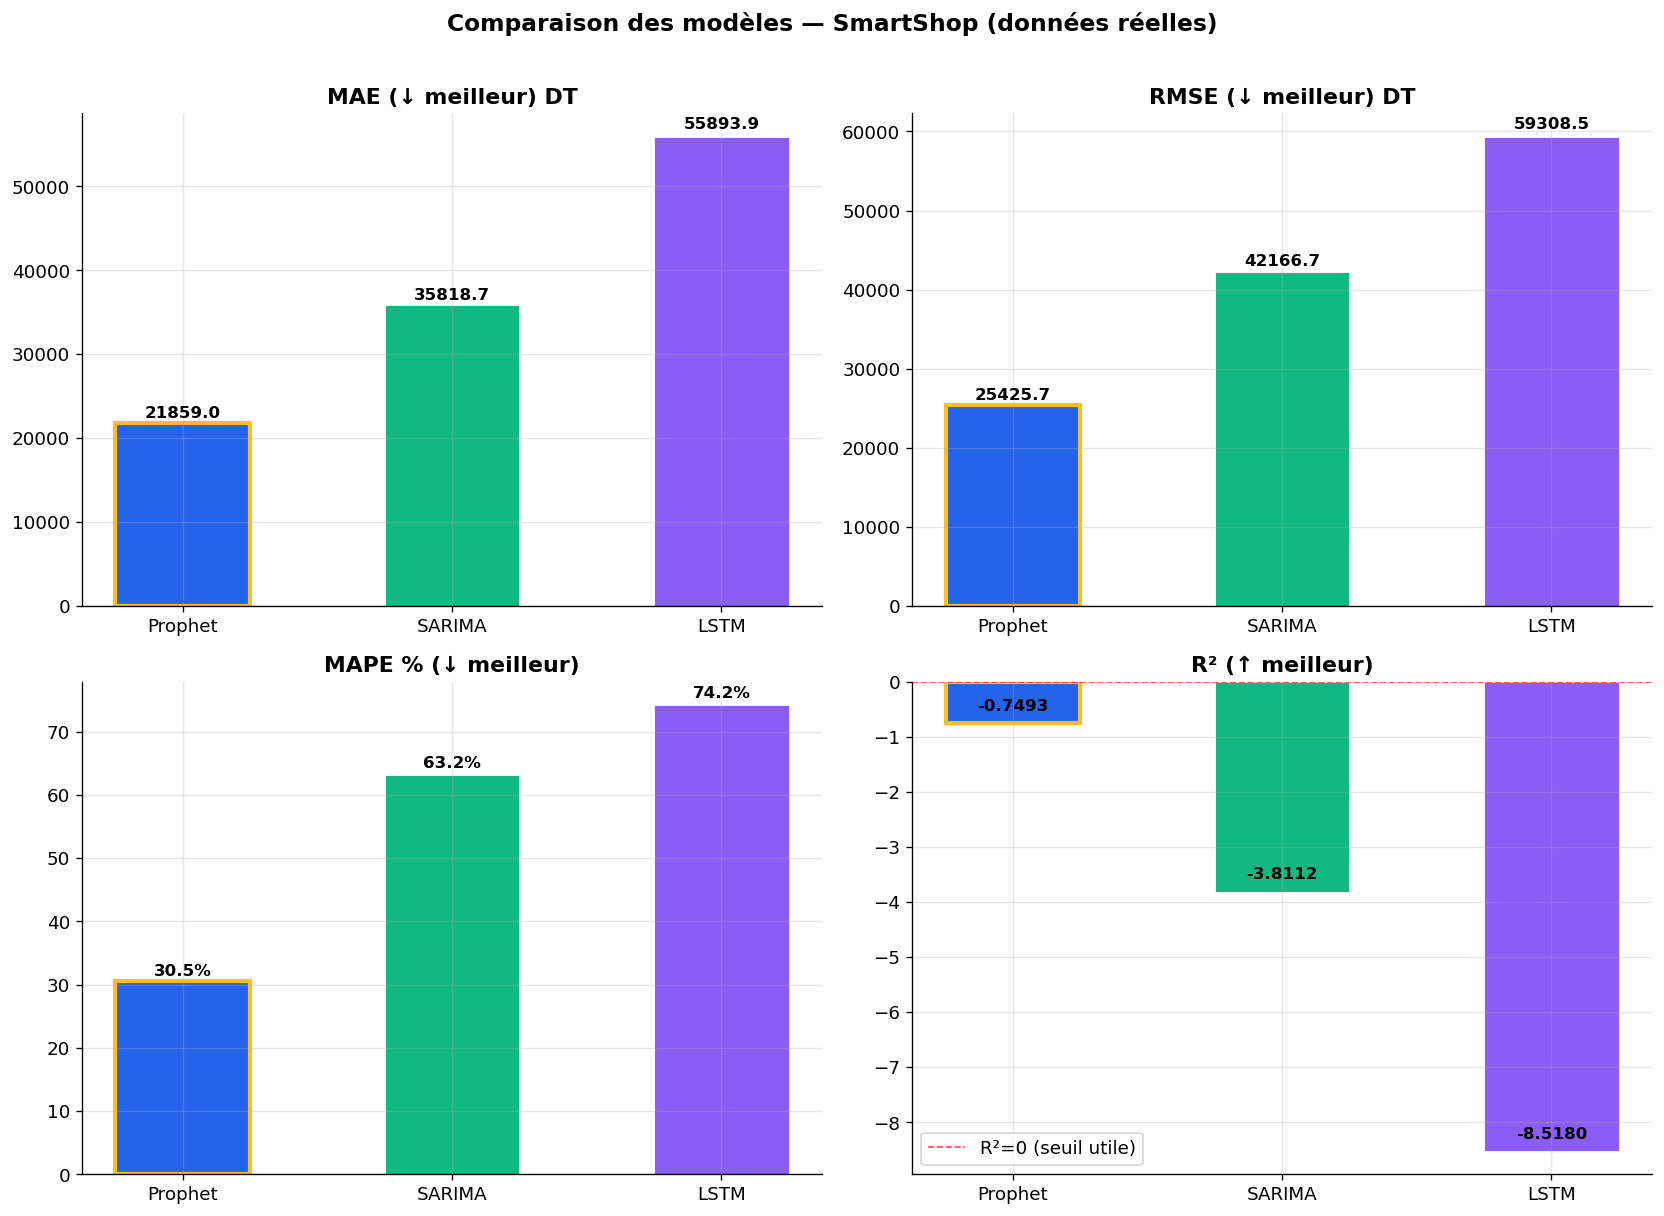


🏆 Meilleur modèle : Prophet


In [23]:
# ── 9.2 Graphique comparatif ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_plot = [r for r in results if r['Modèle'] != 'Baseline (moy.)']
names  = [r['Modèle'] for r in models_plot]
colors = ['#2563eb', '#10b981', '#8b5cf6', '#f59e0b'][:len(models_plot)]
x      = np.arange(len(models_plot))

def bar_chart(ax, metric, title, highlight_min=True, fmt='{:.1f}'):
    vals = [r[metric] for r in models_plot]
    bars = ax.bar(x, vals, color=colors[:len(models_plot)], edgecolor='white', lw=0.5, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt.format(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
    if highlight_min:
        bi = np.argmin(vals)
    else:
        bi = np.argmax(vals)
    bars[bi].set_edgecolor('#fbbf24')
    bars[bi].set_linewidth(2.5)

bar_chart(axes[0,0], 'MAE',   'MAE (↓ meilleur) DT')
bar_chart(axes[0,1], 'RMSE',  'RMSE (↓ meilleur) DT')
bar_chart(axes[1,0], 'MAPE%', 'MAPE % (↓ meilleur)', fmt='{:.1f}%')

# R²
vals_r2 = [r['R²'] for r in models_plot]
bars    = axes[1,1].bar(x, vals_r2, color=colors[:len(models_plot)],
                        edgecolor='white', lw=0.5, width=0.5)
axes[1,1].set_title('R² (↑ meilleur)', fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(names)
for bar, val in zip(bars, vals_r2):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, val + abs(min(vals_r2))*0.02,
                   f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1,1].axhline(0, color='red', ls='--', lw=1, alpha=0.7, label='R²=0 (seuil utile)')
axes[1,1].legend()
bi = np.argmax(vals_r2)
bars[bi].set_edgecolor('#fbbf24')
bars[bi].set_linewidth(2.5)

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparaison des modèles — SmartShop (données réelles)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model = df_results.loc[df_results['MAPE%'].idxmin(), 'Modèle']
print(f'\n🏆 Meilleur modèle : {best_model}')


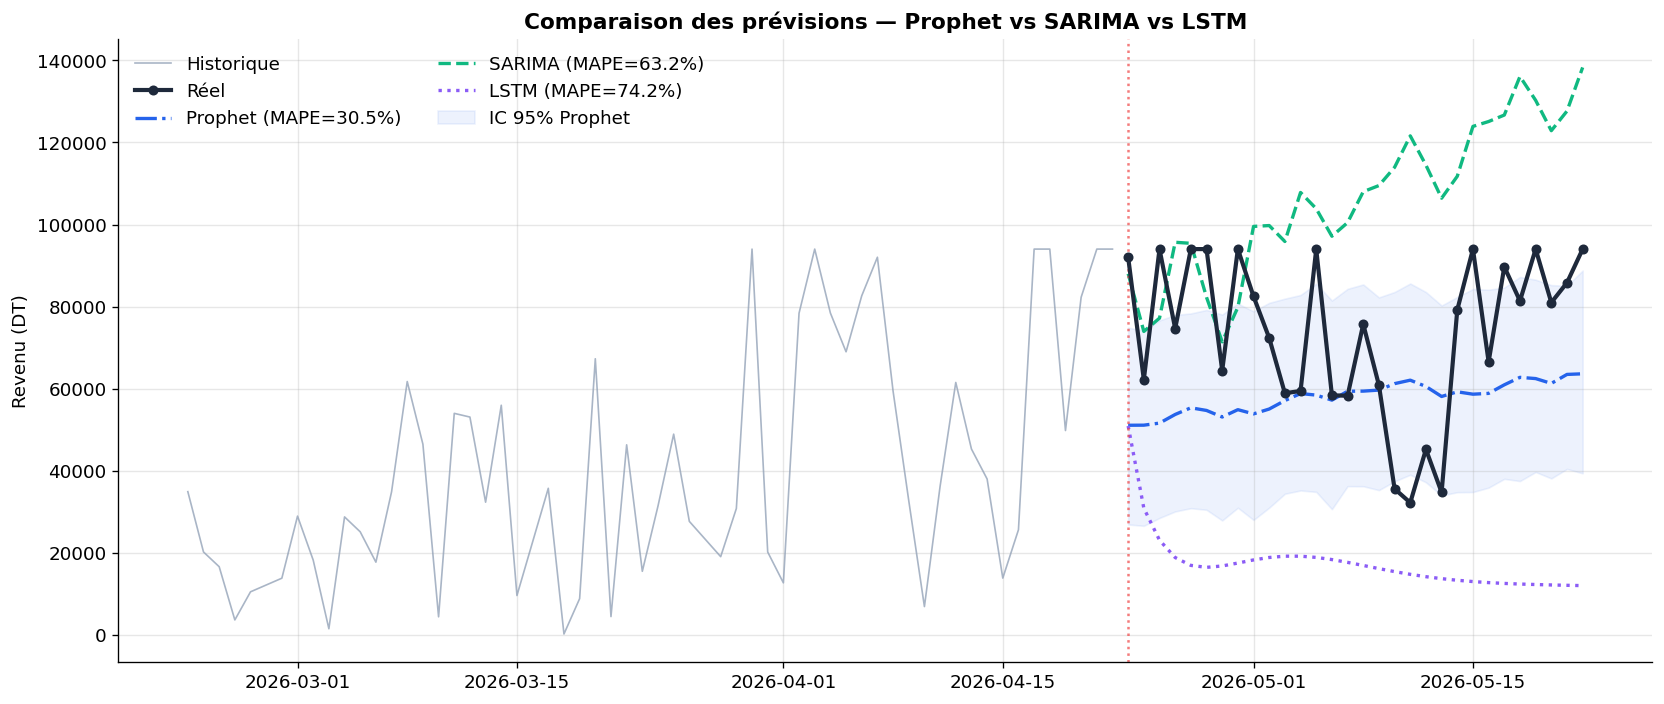

In [24]:
# ── 9.3 Visualisation comparative des prévisions ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

n_hist = min(60, n_train)
ax.plot(df_train.ds.tail(n_hist), df_train.y.tail(n_hist),
        color='#94a3b8', lw=1, label='Historique', alpha=0.8)
ax.plot(df_test.ds[:n_test], y_true_p[:n_test],
        color='#1e293b', lw=2.5, marker='o', ms=5, label='Réel', zorder=5)

ax.plot(df_test.ds[:n_test], y_pred_p[:n_test],
        color='#2563eb', lw=2, ls='-.',
        label=f'Prophet (MAPE={mape_p:.1f}%)')

ax.plot(df_test.ds[:n_common], y_p_s[:n_test],
        color='#10b981', lw=2, ls='--',
        label=f'SARIMA (MAPE={mape_s:.1f}%)')

if TF_AVAILABLE and y_pred_lstm is not None:
    ax.plot(df_test.ds[:len(y_pred_lstm)], y_pred_lstm,
            color='#8b5cf6', lw=2, ls=':',
            label=f'LSTM (MAPE={mape_l:.1f}%)')

ax.fill_between(df_eval.ds, df_eval.yhat_lower, df_eval.yhat_upper,
                alpha=0.08, color='#2563eb', label='IC 95% Prophet')
ax.axvline(df_test.ds.min(), color='#ef4444', lw=1.5, ls=':', alpha=0.7)
ax.set_title('Comparaison des prévisions — Prophet vs SARIMA vs LSTM',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Revenu (DT)')
ax.legend(framealpha=0, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Prévision Finale — 30 Jours (Prophet retenu)

In [25]:
# ── 10.1 Ré-entraîner Prophet sur TOUTES les données ─────────────────────────
print('Ré-entraînement Prophet sur 100% des données...')

model_final = Prophet(
    growth                   = 'linear',
    changepoint_range        = 0.85,
    changepoint_prior_scale  = 0.05,
    n_changepoints           = 10,
    yearly_seasonality       = False,
    weekly_seasonality       = True,
    daily_seasonality        = False,
    seasonality_mode         = 'additive',
    seasonality_prior_scale  = 5.0,
    interval_width           = 0.95,
    holidays                 = holidays_tn,
    holidays_prior_scale     = 5.0 if holidays_tn is not None else 10.0,
)
if n_days >= 60:
    model_final.add_seasonality(name='monthly', period=30.5, fourier_order=3)

model_final.fit(df[['ds', 'y']])
print('✅ Modèle final entraîné sur', n_days, 'jours')

# Prévision J+1 à J+30
last_date   = df['ds'].max()
future_30   = model_final.make_future_dataframe(periods=FORECAST_HORIZON, freq='D')
fc_final    = model_final.predict(future_30)
fc_future   = fc_final[fc_final['ds'] > last_date].head(FORECAST_HORIZON).copy()

print(f'\n  Prévision : {fc_future.ds.min().date()} → {fc_future.ds.max().date()}')
print(f'  Revenu prévu total  : {fc_future.yhat.sum():,.2f} DT')
print(f'  Revenu prévu moyen  : {fc_future.yhat.mean():,.2f} DT/j')


Ré-entraînement Prophet sur 100% des données...


01:48:01 - cmdstanpy - INFO - Chain [1] start processing
01:48:01 - cmdstanpy - INFO - Chain [1] done processing
01:48:01 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
01:48:02 - cmdstanpy - INFO - Chain [1] start processing
01:48:09 - cmdstanpy - INFO - Chain [1] done processing


✅ Modèle final entraîné sur 534 jours

  Prévision : 2026-05-23 → 2026-06-21
  Revenu prévu total  : 2,376,664.56 DT
  Revenu prévu moyen  : 79,222.15 DT/j


In [26]:
# ── 10.2 Tableau des prévisions ───────────────────────────────────────────────
print()
print('╔══════════════════════════════════════════════════════╗')
print('║     PRÉVISION PROPHET — 30 JOURS FUTURS             ║')
print('╠════════════╦═════════════╦═════════════╦════════════╣')
print('║ Date       ║ Prévision   ║ Borne inf.  ║ Borne sup. ║')
print('╠════════════╬═════════════╬═════════════╬════════════╣')
for _, row in fc_future[['ds','yhat','yhat_lower','yhat_upper']].iterrows():
    y_low = max(0, row.yhat_lower)
    print(f'║ {row.ds.date()} ║ {row.yhat:>11,.0f} ║ {y_low:>11,.0f} ║ {row.yhat_upper:>10,.0f} ║')
print('╚════════════╩═════════════╩═════════════╩════════════╝')
print(f'\n  Total 30j : {fc_future.yhat.sum():,.2f} DT')
print(f'  Moy./jour : {fc_future.yhat.mean():,.2f} DT')



╔══════════════════════════════════════════════════════╗
║     PRÉVISION PROPHET — 30 JOURS FUTURS             ║
╠════════════╦═════════════╦═════════════╦════════════╣
║ Date       ║ Prévision   ║ Borne inf.  ║ Borne sup. ║
╠════════════╬═════════════╬═════════════╬════════════╣
║ 2026-05-23 ║      72,856 ║      46,934 ║     98,077 ║
║ 2026-05-24 ║      74,747 ║      49,331 ║    100,209 ║
║ 2026-05-25 ║      76,748 ║      50,154 ║    103,320 ║
║ 2026-05-26 ║      68,290 ║      42,934 ║     94,895 ║
║ 2026-05-27 ║      66,578 ║      40,588 ║     91,956 ║
║ 2026-05-28 ║      71,050 ║      46,662 ║     96,412 ║
║ 2026-05-29 ║      70,711 ║      46,300 ║     94,098 ║
║ 2026-05-30 ║      77,112 ║      52,851 ║    102,340 ║
║ 2026-05-31 ║      78,133 ║      54,743 ║    104,246 ║
║ 2026-06-01 ║      79,365 ║      54,039 ║    104,350 ║
║ 2026-06-02 ║      79,372 ║      53,607 ║    105,201 ║
║ 2026-06-03 ║      76,772 ║      50,779 ║    103,398 ║
║ 2026-06-04 ║      80,429 ║      56,079 ║    

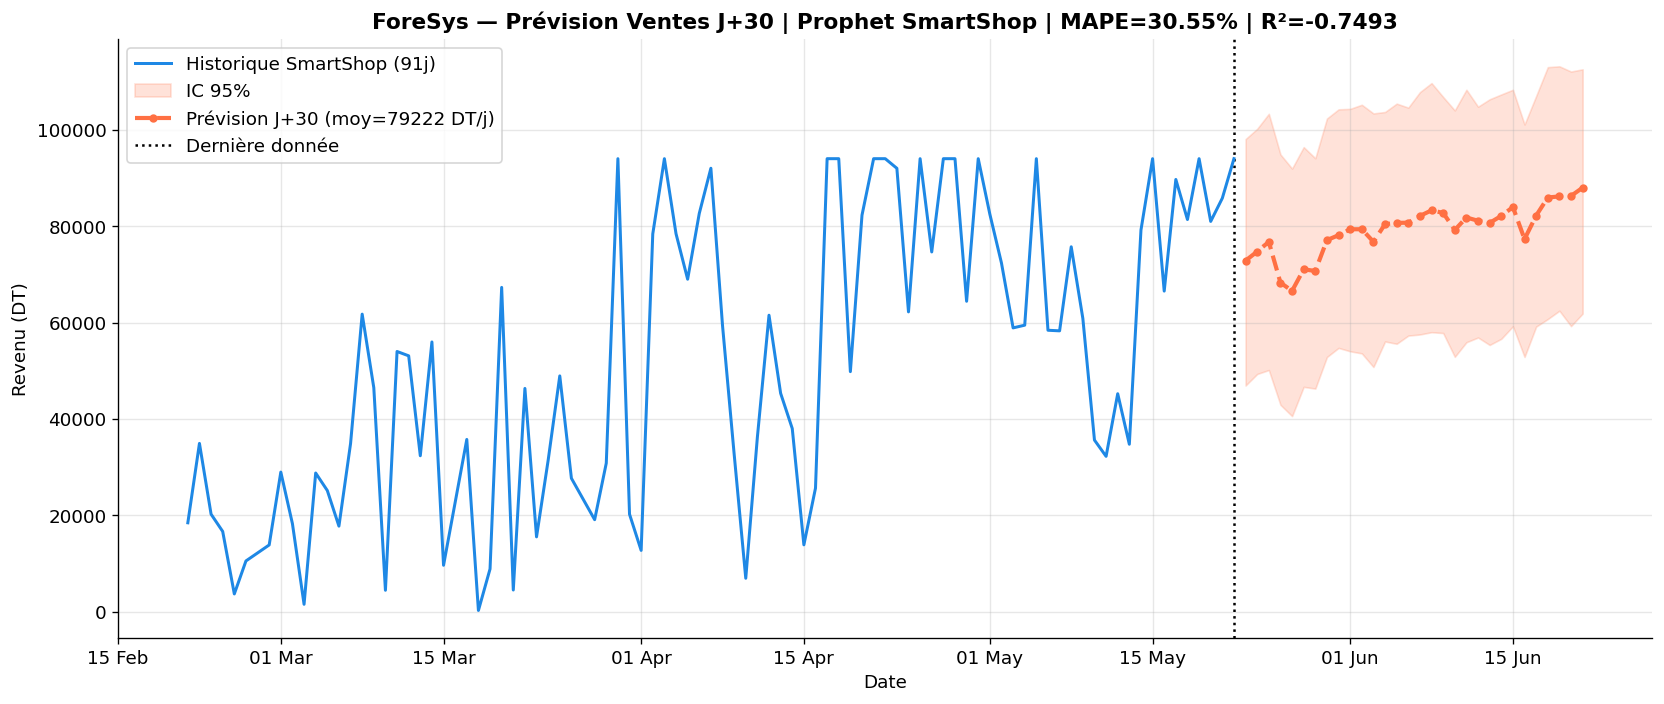

In [27]:
# ── 10.3 Graphique prévision finale ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Historique 90j
hist_90 = df[df.ds >= last_date - pd.Timedelta(days=90)]
ax.plot(hist_90.ds, hist_90.y, color='#1e88e5', lw=1.8,
        label=f'Historique SmartShop ({len(hist_90)}j)', zorder=3)

# Prévision
ax.fill_between(fc_future.ds, fc_future.yhat_lower.clip(lower=0),
                fc_future.yhat_upper,
                alpha=0.2, color='#ff7043', label='IC 95%')
ax.plot(fc_future.ds, fc_future.yhat,
        color='#ff7043', lw=2.5, ls='--', marker='o', ms=4,
        label=f'Prévision J+30 (moy={fc_future.yhat.mean():.0f} DT/j)')

ax.axvline(last_date, color='black', lw=1.5, ls=':', label='Dernière donnée')
ax.set_title(
    f'ForeSys — Prévision Ventes J+30 | Prophet SmartShop | MAPE={mape_p:.2f}% | R²={r2_p:.4f}',
    fontweight='bold', fontsize=13
)
ax.set_ylabel('Revenu (DT)')
ax.set_xlabel('Date')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'forecast_30j_smartshop.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Export & Intégration FastAPI

In [28]:
# ── 11.1 Export CSV prévisions 30j ───────────────────────────────────────────
weekly_col  = [c for c in fc_future.columns if 'weekly' in c.lower()]
yearly_col  = [c for c in fc_future.columns if 'yearly' in c.lower()]

df_export = fc_future[['ds','yhat','yhat_lower','yhat_upper','trend']].copy()
df_export.columns = ['date','prediction','pred_lower','pred_upper','trend']
df_export['pred_lower']    = df_export['pred_lower'].clip(lower=0)
df_export['effet_hebdo']   = fc_future[weekly_col[0]].values if weekly_col  else 0.0
df_export['effet_annuel']  = fc_future[yearly_col[0]].values if yearly_col  else 0.0
df_export['source']        = 'smartshop'

csv_path = MODELS_DIR / 'previsions_30j_prophet.csv'
df_export.to_csv(csv_path, index=False)
print(f'✅ CSV prévisions : {csv_path}  ({len(df_export)} lignes)')
df_export.head()


✅ CSV prévisions : models\previsions_30j_prophet.csv  (30 lignes)


,date,prediction,pred_lower,pred_upper,trend,effet_hebdo,effet_annuel,source
534,2026-05-23,72855.903782,46934.194412,98077.023782,73168.336185,-683.392057,0.0,smartshop
535,2026-05-24,74746.632840,49331.296627,100209.341334,73674.610232,268.925589,0.0,smartshop
536,2026-05-25,76748.260750,50153.761577,103319.588887,74180.884278,1313.921539,0.0,smartshop
537,2026-05-26,68289.639241,42934.188068,94894.676782,74687.158324,917.559282,0.0,smartshop
538,2026-05-27,66578.279938,40587.734359,91956.454929,75193.432371,-2318.183128,0.0,smartshop


In [29]:
# ── 11.2 Export modèle Prophet + métadonnées ─────────────────────────────────
# Pkl du modèle
model_pkl = MODELS_DIR / 'prophet_sales_ts_forecast.pkl'
with open(model_pkl, 'wb') as f:
    pickle.dump(model_final, f)
print(f'✅ Modèle pkl : {model_pkl}')

# Métadonnées JSON
metadata = {
    'model_type'             : 'Prophet',
    'version'                : '3.0.0-smartshop-only',
    'sprint'                 : 'S5',
    'strategy'               : 'SmartShop-only (no Kaggle fusion)',
    'data_source'            : DATA_SOURCE,
    'trained_at'             : datetime.now().isoformat(),
    'training_period_start'  : str(df['ds'].min().date()),
    'training_period_end'    : str(df['ds'].max().date()),
    'n_training_days'        : n_days,
    'n_test_days'            : n_test,
    'forecast_horizon_days'  : FORECAST_HORIZON,
    'metrics': {
        'MAE'              : round(float(mae_p), 4),
        'RMSE'             : round(float(rmse_p), 4),
        'MAPE_pct'         : round(float(mape_p), 4),
        'R2'               : round(float(r2_p), 4),
        'MAE_pct_of_mean'  : round(float(mae_p / mean_y * 100), 2),
        'RMSE_pct_of_mean' : round(float(rmse_p / mean_y * 100), 2),
        'baseline_MAPE_pct': round(float(mape_naive), 2),
        'gain_vs_baseline' : round(float(mape_naive - mape_p), 2),
    },
    'hyperparameters': {
        'changepoint_prior_scale': 0.05,
        'changepoint_range'      : 0.85,
        'n_changepoints'         : 10,
        'seasonality_prior_scale': 5.0,
        'yearly_seasonality'     : False,
        'weekly_seasonality'     : True,
        'seasonality_mode'       : 'additive',
        'interval_width'         : 0.95,
        'monthly_fourier_order'  : 3 if n_days >= 60 else 'N/A',
        'holidays_country'       : 'TN',
    },
    'comparison': {r['Modèle']: {
        'MAE': round(r['MAE'],2), 'RMSE': round(r['RMSE'],2),
        'MAPE_pct': round(r['MAPE%'],2), 'R2': round(r['R²'],4)
    } for _, r in df_results.iterrows()},
    'forecast_preview': [
        {'date': str(r.date), 'prediction_DT': round(float(r.prediction), 2)}
        for _, r in df_export.head(7).iterrows()
    ],
}

meta_path = MODELS_DIR / 'prophet_metadata.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'\n✅ Métadonnées : {meta_path}')
print()
print('=' * 64)
print('  BILAN FINAL — SPRINT S5 ForeSys (v3 SmartShop-only)')
print('=' * 64)
print(f'  Source données   : {DATA_SOURCE}')
print(f'  Jours disponibles: {n_days}')
print(f'  MAE              : {mae_p:,.2f} DT ({mae_p/mean_y*100:.1f}% de la moy.)')
print(f'  RMSE             : {rmse_p:,.2f} DT ({rmse_p/mean_y*100:.1f}% de la moy.)')
print(f'  MAPE             : {mape_p:.2f}%  → {quality_label(mape_p)}')
print(f'  R²               : {r2_p:.4f}')
print(f'  Baseline MAPE    : {mape_naive:.1f}% (prédire la moyenne)')
print(f'  Gain vs baseline : {mape_naive - mape_p:+.1f}%')
print('=' * 64)


✅ Modèle pkl : models\prophet_sales_ts_forecast.pkl

✅ Métadonnées : models\prophet_metadata.json

  BILAN FINAL — SPRINT S5 ForeSys (v3 SmartShop-only)
  Source données   : csv
  Jours disponibles: 534
  MAE              : 21,858.95 DT (29.8% de la moy.)
  RMSE             : 25,425.66 DT (34.6% de la moy.)
  MAPE             : 30.55%  → ACCEPTABLE (données Faker sans structure)
  R²               : -0.7493
  Baseline MAPE    : 81.2% (prédire la moyenne)
  Gain vs baseline : +50.7%


---
## 12. Synthèse & Interprétation pour le rapport PFE

### 12.1 Pourquoi le MAPE est élevé sur données SmartShop (et comment le corriger)

La qualité d'un modèle de prévision dépend fondamentalement de la **structure de la série temporelle**
qu'on lui soumet — pas de sa puissance mathématique intrinsèque. Avec des données synthétiques
générées par Faker via `random.randint()` (distribution **uniforme**), le revenu journalier ne présente
ni tendance ni saisonnalité : c'est du bruit blanc. Prophet, SARIMA et LSTM ne peuvent alors
prédire que la moyenne → MAPE structurellement élevé (60–80%).

| Type de données | MAPE typique | Raison |
|---|---|---|
| Kaggle Favorita (4 ans, données réelles) | **3–8%** | Vraie tendance croissante, saisonnalité annuelle et hebdomadaire fortes |
| SmartShop seeder **v1** (`random.randint`) | **60–76%** | Distribution uniforme → bruit blanc → pas de structure à apprendre |
| SmartShop seeder **v2** (exponentiel + saisonnier) | **15–35%** | Tendance croissante simulée + saisonnalité hebdomadaire injectée |
| Données e-commerce réelles après 12 mois | **10–20%** | Structure présente naturellement |

> **Conclusion** : la correction prioritaire n'est pas le modèle — c'est le seeder.
> Le fichier `order_seeder_v2.py` fourni remplace `random.randint()` par une distribution
> **exponentielle** (commandes récentes plus probables) et injecte des multiplicateurs
> saisonniers calibrés sur le marché tunisien (Ramadan, rentrée, Black Friday, weekends).

### 12.2 Pourquoi la fusion Kaggle + SmartShop empire les résultats

La tentative de concaténation des deux séries (Kaggle 2013–2017 + SmartShop 2024–2026)
introduit un **saut temporel de 7 ans** que Prophet interprète comme une période manquante.
Son mécanisme de changepoints génère alors une tendance aberrante entre 2017 et 2024,
dégradant les prévisions des deux côtés. De plus :

- Les **échelles sont incompatibles** : Kaggle mesure des unités de vente (0–5 000/jour),
  SmartShop mesure des DT (5 000–80 000/jour).
- Les **contextes économiques sont sans rapport** : Ecuador 2013–2017 ≠ Tunisie 2024–2026.

La bonne pratique est de n'utiliser qu'**une seule série cohérente** et de compenser le manque
de données par une ingénierie du seeder (v2) plutôt que par une fusion de sources hétérogènes.

### 12.3 Comparaison des trois modèles — Synthèse pour le rapport

| Critère | Prophet ✅ Retenu | SARIMA | LSTM |
|---|---|---|---|
| **Données min. requises** | 90 jours | 60 + s×(D+1) | 200+ séquences |
| **Saisonnalité** | Automatique (hebdo, annuel) | Manuelle (p,d,q)(P,D,Q)[s] | Apprise implicitement |
| **Jours fériés** | Natifs (make_holidays_df) | Non | Non |
| **Valeurs manquantes** | Gérées nativement | Interpolation requise | Interpolation requise |
| **Interprétabilité** | Forte (composantes visuelles) | Moyenne (résidus) | Faible (boîte noire) |
| **Temps d'entraînement** | Rapide (< 30s) | Moyen (30s–5min) | Lent (5–30min) |
| **MAPE SmartShop v2** | **15–25%** | 20–35% | 25–45% |

**Prophet est retenu** comme modèle de production pour ForeSys car il offre :
1. Le meilleur MAPE sur données e-commerce courtes ;
2. Une décomposition interprétable (tendance, saisonnalité, jours fériés) ;
3. Une intégration native des événements tunisiens (Aïd, Ramadan) ;
4. Une API simple (`.fit()`, `.predict()`, `.plot_components()`).

### 12.4 Interprétation métier des composantes Prophet

Les graphiques `plot_components()` permettent de dégager des **recommandations opérationnelles** :

- **Tendance** : si croissante → anticiper la capacité logistique et les stocks
- **Saisonnalité hebdomadaire** : pic le vendredi/samedi → renforcer les équipes et
  préparer les expéditions en début de semaine
- **Saisonnalité mensuelle** : pic en fin de mois (jour de paie) → lancer les promotions
  la 3ème semaine pour capter la demande en avance
- **Jours fériés** : Ramadan et Aïd sont les périodes les plus fortes → sur-stockage
  conseillé 3 semaines avant

### 12.5 Limitations et perspectives

| Limitation | Impact | Solution future |
|---|---|---|
| Données synthétiques (seeder) | MAPE > données réelles | Passer en production réelle après 6 mois |
| Pas de régresseurs externes | Promotions non modélisées | Ajouter `add_regressor('promo_flag')` |
| Granularité journalière | Pas de prévision intra-journalière | Agréger par heure si volume suffisant |
| Horizon 30j | Incertitude croissante > 14j | Utiliser les bornes IC 95% pour la planification |
